# 🖊️ Handwritten Character Recognition using CRNN
### CNN–RNN Hybrid (CRNN) Architecture · EMNIST Dataset · CTC Loss

---

**Team:**  
Chanda Akhil · Revan Reddy · Farhan Khan · Jeevan Reddy · Devaguru Nanduri

**Subject:** Deep Learning

---

### Pipeline
```
EMNIST Dataset → Preprocessing → CNN Feature Extraction → BiLSTM Sequence Modeling → CTC Loss → Prediction
```

### Run order
Just run all cells top to bottom: **Kernel → Restart & Run All**

## Cell 1 — Install Dependencies

In [11]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('torch')
install('torchvision')
install('tqdm')
install('ipywidgets')        # ← ADD THIS LINE
install('matplotlib')
install('Pillow')
install('numpy')

print('✅ All dependencies installed')

✅ All dependencies installed


## Cell 2 — Imports & Device Setup

In [12]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.datasets as tvd
from tqdm.auto import tqdm

# ── Device selection (auto-detects CUDA / Apple MPS / CPU) ──
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')   # Apple Silicon GPU
else:
    DEVICE = torch.device('cpu')

CTC_DEVICE = torch.device('cpu')   # CTCLoss not supported on MPS — always CPU

print(f'🖥️  Device      : {DEVICE}')
print(f'🔢  PyTorch     : {torch.__version__}')
print(f'🍎  MPS available: {torch.backends.mps.is_available()}')

🖥️  Device      : mps
🔢  PyTorch     : 2.8.0
🍎  MPS available: True


/Users/devaguru/ML_Lab/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 3 — Configuration (edit these to change training settings)

In [ ]:
# ════════════════════════════════════════════════
#  CONFIG — change these values as needed
# ════════════════════════════════════════════════

DATA_ROOT   = './data/emnist'   # EMNIST auto-downloads here (~560 MB)
SAVE_DIR    = './checkpoints'

IMG_H       = 32                # image height fed to model
IMG_W       = 32                # image width  (32×32 for single chars)

BATCH_SIZE  = 128
EPOCHS      = 20                # increase to 30 for full training
LR          = 3e-4
NUM_WORKERS = 0                 # 0 = safe for all OS; increase on Linux/Mac

# Subset size — use None to train on ALL 697k samples (slower)
MAX_TRAIN   = 200000             # ~10 min on MPS per epoch with 60k
MAX_VAL     = 20000

os.makedirs(SAVE_DIR, exist_ok=True)

print('⚙️  Config loaded')
print(f'   Epochs     : {EPOCHS}')
print(f'   Batch size : {BATCH_SIZE}')
print(f'   Max train  : {MAX_TRAIN:,}')
print(f'   Max val    : {MAX_VAL:,}')

⚙️  Config loaded
   Epochs     : 15
   Batch size : 128
   Max train  : 60,000
   Max val    : 10,000


## Cell 4 — Character Vocabulary & Encoding

In [15]:
# EMNIST ByClass order: 0-9, A-Z, a-z  (62 characters)
CHARS        = '0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz'
BLANK_IDX    = 0                           # CTC blank token at index 0
CHAR2IDX     = {c: i + 1 for i, c in enumerate(CHARS)}
IDX2CHAR     = {i + 1: c for i, c in enumerate(CHARS)}
NUM_CLASSES  = len(CHARS) + 1             # 63  (62 chars + blank)

def encode(text):
    """Convert string → list of integer indices."""
    return [CHAR2IDX[c] for c in text if c in CHAR2IDX]

def decode_ctc(indices):
    """Greedy CTC decode: collapse repeated tokens, remove blanks."""
    result, prev = [], None
    for idx in indices:
        idx = int(idx)
        if idx != prev and idx != BLANK_IDX:
            result.append(IDX2CHAR.get(idx, '?'))
        prev = idx
    return ''.join(result)

print(f'📚 Vocabulary size : {NUM_CLASSES} (including CTC blank)')
print(f'   Characters      : {CHARS}')
print(f'   Encode test     : encode("Hello") = {encode("Hello")}')
print(f'   Decode test     : decode_ctc([{encode("Hi")[0]}, 0, {encode("Hi")[1]}]) = "{decode_ctc([encode("Hi")[0], 0, encode("Hi")[1]])}\'"')

📚 Vocabulary size : 63 (including CTC blank)
   Characters      : 0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
   Encode test     : encode("Hello") = [18, 41, 48, 48, 51]
   Decode test     : decode_ctc([18, 0, 45]) = "Hi'"


## Cell 5 — Dataset: EMNIST (Auto-Download)

In [16]:
# ── Image transforms ─────────────────────────────────────────────────────────
def make_transform(train, h=IMG_H, w=IMG_W):
    ops = [T.Grayscale(), T.Resize((h, w))]
    if train:
        ops += [
            T.RandomAffine(degrees=5, translate=(0.03, 0.03), shear=5),
            T.ColorJitter(brightness=0.3, contrast=0.3),
            T.GaussianBlur(3, sigma=(0.1, 1.0)),
        ]
    ops += [T.ToTensor(), T.Normalize([0.5], [0.5])]
    return T.Compose(ops)


def collate_fn(batch):
    images, labels, lengths, texts = zip(*batch)
    return (
        torch.stack(images, 0),
        torch.cat(labels),
        torch.tensor(lengths, dtype=torch.long),
        list(texts),
    )


# ── EMNIST Dataset wrapper ───────────────────────────────────────────────────
EMNIST_CHARS = list('0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz')

class EMNISTDataset(Dataset):
    """
    Wraps torchvision EMNIST 'byclass' (62 classes).
    Auto-downloads ~560 MB on first call.
    """
    def __init__(self, train=True, max_samples=None):
        self.tfm = make_transform(train)
        self.base = tvd.EMNIST(
            root=DATA_ROOT, split='byclass',
            train=train, download=True, transform=None
        )
        n = len(self.base)
        idx = torch.randperm(n)[:max_samples].tolist() if max_samples and max_samples < n else list(range(n))
        self.idx = idx

    def __len__(self): return len(self.idx)

    def __getitem__(self, i):
        img_pil, label_int = self.base[self.idx[i]]
        if not isinstance(img_pil, Image.Image):
            img_pil = T.ToPILImage()(img_pil)
        img_pil = img_pil.transpose(Image.TRANSPOSE)  # EMNIST fix
        img = self.tfm(img_pil)
        char = EMNIST_CHARS[label_int] if label_int < len(EMNIST_CHARS) else '0'
        enc  = encode(char) or [1]
        return img, torch.tensor(enc, dtype=torch.long), len(enc), char


# ── Download & create loaders ────────────────────────────────────────────────
print('📥 Loading EMNIST dataset (downloading if first time)...')
pin = torch.cuda.is_available()

train_ds = EMNISTDataset(train=True,  max_samples=MAX_TRAIN)
val_ds   = EMNISTDataset(train=False, max_samples=MAX_VAL)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, collate_fn=collate_fn,
                      pin_memory=pin, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, collate_fn=collate_fn,
                      pin_memory=pin)

print(f'✅ Train samples : {len(train_ds):,}  ({len(train_dl):,} batches)')
print(f'✅ Val   samples : {len(val_ds):,}  ({len(val_dl):,} batches)')

📥 Loading EMNIST dataset (downloading if first time)...
✅ Train samples : 60,000  (468 batches)
✅ Val   samples : 10,000  (79 batches)


## Cell 6 — Visualise Sample Images

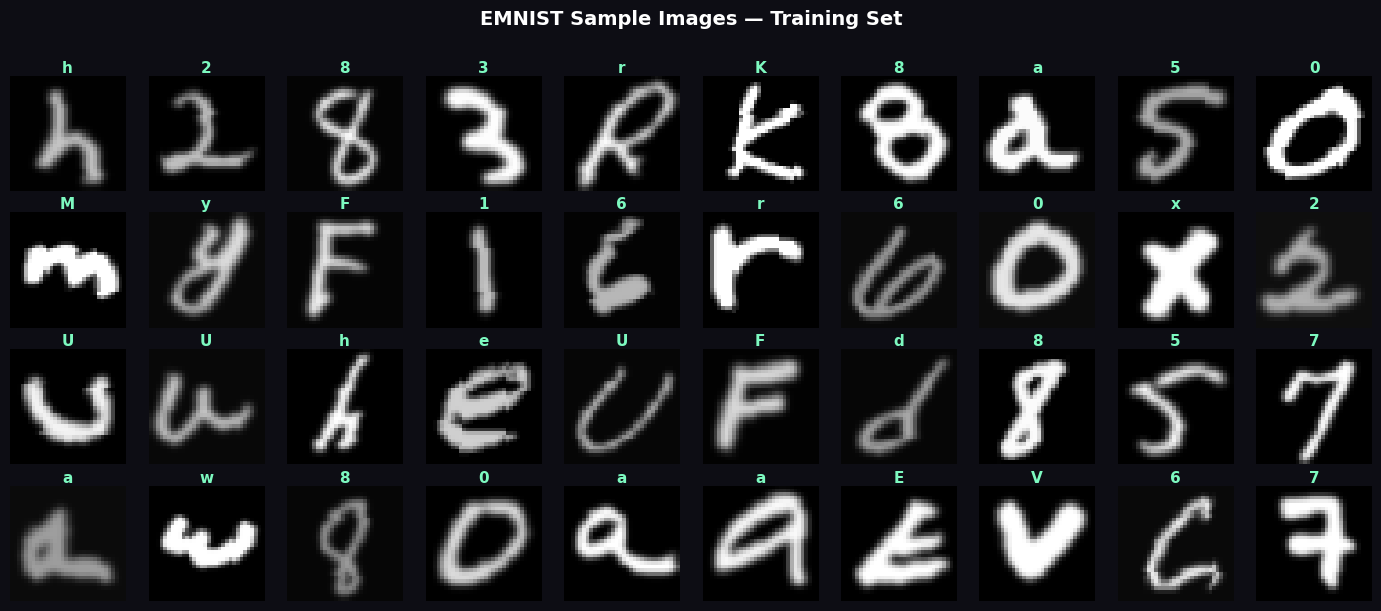

Sample labels: ['h', '2', '8', '3', 'r', 'K', '8', 'a', '5', '0', 'M', 'y', 'F', '1', '6', 'r', '6', '0', 'x', '2']


In [17]:
# Show a grid of 40 sample images from the training set
imgs, labels, lengths, texts = next(iter(train_dl))

fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.patch.set_facecolor('#0d0d14')
fig.suptitle('EMNIST Sample Images — Training Set', color='white',
             fontsize=14, fontweight='bold', y=1.01)

for i, ax in enumerate(axes.flat):
    img = imgs[i].squeeze().numpy()
    img = (img * 0.5) + 0.5          # unnormalize
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(texts[i], color='#7DF9C0', fontsize=11, fontweight='bold', pad=2)
    ax.axis('off')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print(f'Sample labels: {texts[:20]}')

## Cell 7 — CRNN Model Architecture

In [18]:
class BidirectionalLSTM(nn.Module):
    def __init__(self, in_size, hidden, out_size):
        super().__init__()
        self.lstm   = nn.LSTM(in_size, hidden, bidirectional=True, batch_first=False)
        self.linear = nn.Linear(hidden * 2, out_size)

    def forward(self, x):               # x: (T, B, in_size)
        out, _ = self.lstm(x)           # (T, B, hidden*2)
        T, B, H = out.shape
        out = self.linear(out.view(T * B, H))
        return out.view(T, B, -1)


class CRNN(nn.Module):
    """
    CNN-RNN Hybrid for Handwritten Character Recognition.

    Architecture:
      Input  (B, 1, 32, 32)
        → CNN Backbone  7 conv blocks → (B, 512, 1, W')
        → Squeeze height              → (W', B, 512)
        → BiLSTM × 2                  → (W', B, num_classes)
        → CTC Loss (training) / Greedy decode (inference)
    """
    def __init__(self, num_classes=NUM_CLASSES, hidden=256):
        super().__init__()

        def cbn(ic, oc, k=3, s=1, p=1):   # Conv + BN + ReLU block
            return nn.Sequential(
                nn.Conv2d(ic, oc, k, s, p, bias=False),
                nn.BatchNorm2d(oc),
                nn.ReLU(inplace=True),
            )

        self.cnn = nn.Sequential(
            cbn(1,   64),  nn.MaxPool2d(2, 2),          # → H/2
            cbn(64,  128), nn.MaxPool2d(2, 2),          # → H/4
            cbn(128, 256), cbn(256, 256),
            nn.MaxPool2d((2,1),(2,1)),                   # → H/8
            cbn(256, 512), cbn(512, 512),
            nn.MaxPool2d((2,1),(2,1)),                   # → H/16
            nn.Conv2d(512, 512, 2, bias=False),         # → H=1
            nn.BatchNorm2d(512), nn.ReLU(inplace=True),
        )

        self.rnn = nn.Sequential(
            BidirectionalLSTM(512,    hidden, hidden),
            BidirectionalLSTM(hidden, hidden, num_classes),
        )

    def forward(self, x):               # x: (B, 1, H, W)
        f = self.cnn(x)                 # (B, 512, 1, W')
        assert f.size(2) == 1, f'Height must be 1, got {f.size(2)}'
        f = f.squeeze(2).permute(2, 0, 1)  # (W', B, 512)
        return self.rnn(f)              # (W', B, num_classes)


model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print('🧠 CRNN Model built successfully')
print(f'   Parameters  : {n_params:,}')
print(f'   Device      : {DEVICE}')
print(f'   Num classes : {NUM_CLASSES}')
print()

# Quick forward-pass sanity check
with torch.no_grad():
    dummy = torch.zeros(4, 1, IMG_H, IMG_W).to(DEVICE)
    out   = model(dummy)
print(f'   Input  shape : {tuple(dummy.shape)}')
print(f'   Output shape : {tuple(out.shape)}  → (Time, Batch, Classes)')

🧠 CRNN Model built successfully
   Parameters  : 8,344,319
   Device      : mps
   Num classes : 63

   Input  shape : (4, 1, 32, 32)
   Output shape : (7, 4, 63)  → (Time, Batch, Classes)


## Cell 8 — Training Utilities (Loss, Metrics, Optimizer)

In [19]:
# ── Loss & Optimizer ─────────────────────────────────────────────────────────
criterion = nn.CTCLoss(blank=0, zero_infinity=True)   # always runs on CPU
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
scaler    = torch.amp.GradScaler('cuda', enabled=(DEVICE.type == 'cuda'))


# ── Metrics ──────────────────────────────────────────────────────────────────
def edit_distance(s1, s2):
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, n + 1):
            prev, dp[j] = dp[j], (prev if s1[i-1] == s2[j-1]
                                   else 1 + min(prev, dp[j], dp[j-1]))
    return dp[n]

def compute_metrics(preds, targets):
    dist  = sum(edit_distance(p, t) for p, t in zip(preds, targets))
    chars = sum(len(t) for t in targets)
    exact = sum(p == t for p, t in zip(preds, targets))
    return dist / max(chars, 1), exact / len(preds)   # CER, Accuracy


# ── Train & Val step functions ────────────────────────────────────────────────
def train_one_epoch(pbar):
    model.train()
    total, n = 0.0, 0
    for imgs, labels, lengths, _ in pbar:
        imgs    = imgs.to(DEVICE)
        labels  = labels.to(CTC_DEVICE)
        lengths = lengths.to(CTC_DEVICE)

        logits = model(imgs)
        T, B, _ = logits.shape
        input_len = torch.full((B,), T, dtype=torch.long, device=CTC_DEVICE)
        log_probs = logits.log_softmax(2).to(CTC_DEVICE)
        loss = criterion(log_probs, labels, input_len, lengths)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()

        total += loss.item(); n += 1
        pbar.set_postfix(loss=f'{loss.item():.4f}', avg=f'{total/n:.4f}')
    return total / max(n, 1)


@torch.no_grad()
def val_one_epoch(pbar):
    model.eval()
    total, preds, targets = 0.0, [], []
    for imgs, labels, lengths, raw in pbar:
        imgs    = imgs.to(DEVICE)
        labels  = labels.to(CTC_DEVICE)
        lengths = lengths.to(CTC_DEVICE)

        logits    = model(imgs)
        T, B, _   = logits.shape
        input_len = torch.full((B,), T, dtype=torch.long, device=CTC_DEVICE)
        log_probs = logits.log_softmax(2).to(CTC_DEVICE)
        loss = criterion(log_probs, labels, input_len, lengths)
        total += loss.item()

        ids = logits.softmax(2).argmax(2).permute(1, 0).cpu()
        for row in ids: preds.append(decode_ctc(row))
        targets.extend(raw)

    cer, acc = compute_metrics(preds, targets)
    return total / len(val_dl), cer, acc


print('✅ Loss, optimizer, metrics ready')

✅ Loss, optimizer, metrics ready


## Cell 9 — Train the Model 🚀

In [21]:
history = {'tr_loss': [], 'va_loss': [], 'cer': [], 'acc': []}
best_acc, best_path = 0.0, os.path.join(SAVE_DIR, 'best_crnn.pth')

print(f'🚀 Starting training for {EPOCHS} epochs')
print(f'   {len(train_dl):,} train batches · {len(val_dl):,} val batches per epoch')
print(f'   Checkpoint → {best_path}')
print('─' * 70)

epoch_bar = tqdm(range(1, EPOCHS + 1), desc='Overall', position=0)

for epoch in epoch_bar:
    t0 = time.time()

    # ── Train ──
    tr_pbar = tqdm(train_dl, desc=f'Ep {epoch:02d} Train',
                   leave=False, position=1)
    tr_loss = train_one_epoch(tr_pbar)

    # ── Validate ──
    va_pbar = tqdm(val_dl, desc=f'Ep {epoch:02d} Val  ',
                   leave=False, position=1)
    va_loss, cer, acc = val_one_epoch(va_pbar)

    scheduler.step()
    elapsed = time.time() - t0

    history['tr_loss'].append(tr_loss)
    history['va_loss'].append(va_loss)
    history['cer'].append(cer)
    history['acc'].append(acc)

    marker = '  ✅ BEST' if acc > best_acc else ''
    print(
        f'Epoch {epoch:02d}/{EPOCHS}  '
        f'tr={tr_loss:.4f}  va={va_loss:.4f}  '
        f'CER={cer:.4f}  Acc={acc*100:.2f}%  '
        f'[{elapsed:.0f}s]{marker}'
    )

    if acc > best_acc:
        best_acc = acc
        torch.save({
            'epoch': epoch, 'model_state': model.state_dict(),
            'accuracy': acc, 'cer': cer,
        }, best_path)

print('\n' + '─' * 70)
print(f'🏆 Training complete!  Best Accuracy: {best_acc*100:.2f}%')
print(f'💾 Best checkpoint saved → {best_path}')

🚀 Starting training for 15 epochs
   468 train batches · 79 val batches per epoch
   Checkpoint → ./checkpoints/best_crnn.pth
──────────────────────────────────────────────────────────────────────


Overall:   7%|▋         | 1/15 [00:59<13:55, 59.67s/it]

Epoch 01/15  tr=0.9127  va=0.6861  CER=0.2177  Acc=78.23%  [60s]  ✅ BEST


Overall:  13%|█▎        | 2/15 [01:58<12:47, 59.03s/it]

Epoch 02/15  tr=0.5991  va=0.5305  CER=0.1788  Acc=82.12%  [58s]  ✅ BEST


...

Epoch 13/15  tr=0.3181  va=0.3805  CER=0.1432  Acc=85.68%  [116s]  ✅ BEST


Overall:  93%|█████████▎| 14/15 [21:06<01:46, 106.76s/it]

Epoch 14/15  tr=0.3152  va=0.3787  CER=0.1421  Acc=85.79%  [118s]  ✅ BEST


Overall: 100%|██████████| 15/15 [22:36<00:00, 90.43s/it] 

Epoch 15/15  tr=0.3122  va=0.3790  CER=0.1429  Acc=85.71%  [90s]

──────────────────────────────────────────────────────────────────────
🏆 Training complete!  Best Accuracy: 85.79%
💾 Best checkpoint saved → ./checkpoints/best_crnn.pth


## Cell 10 — Plot Training Curves

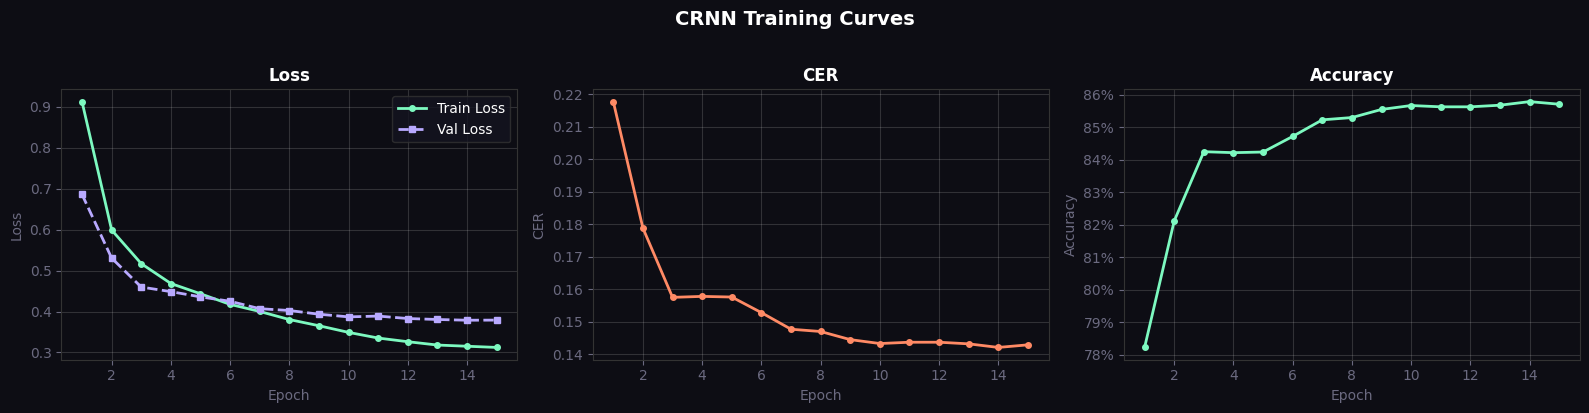

Final → Accuracy: 85.71%  CER: 0.1429


In [22]:
epochs_x = list(range(1, len(history['acc']) + 1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.patch.set_facecolor('#0d0d14')

styles = [
    ('tr_loss', 'va_loss', 'Loss',     'Train Loss', 'Val Loss', '#7DF9C0', '#B8A9FF'),
    ('cer',     None,      'CER',      'CER',        None,       '#FF8A65', None),
    ('acc',     None,      'Accuracy', 'Accuracy',   None,       '#7DF9C0', None),
]

for ax, (k1, k2, ylabel, l1, l2, c1, c2) in zip(axes, styles):
    ax.set_facecolor('#0d0d14')
    ax.plot(epochs_x, history[k1], color=c1, lw=2, label=l1, marker='o', ms=4)
    if k2:
        ax.plot(epochs_x, history[k2], color=c2, lw=2, label=l2,
                marker='s', ms=4, linestyle='--')
    if ylabel == 'Accuracy':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y*100:.0f}%'))
    ax.set_xlabel('Epoch', color='#6b6a80')
    ax.set_ylabel(ylabel, color='#6b6a80')
    ax.set_title(ylabel, color='white', fontweight='bold')
    ax.tick_params(colors='#6b6a80')
    for spine in ax.spines.values(): spine.set_edgecolor('#333')
    ax.grid(True, alpha=0.15, color='white')
    if k2: ax.legend(facecolor='#141420', labelcolor='white', edgecolor='#333')

plt.suptitle('CRNN Training Curves', color='white', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print(f'Final → Accuracy: {history["acc"][-1]*100:.2f}%  CER: {history["cer"][-1]:.4f}')

## Cell 11 — Load Best Checkpoint & Run Inference

In [23]:
# Load the best saved checkpoint
ckpt = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f'✅ Loaded best checkpoint')
print(f'   Epoch    : {ckpt["epoch"]}')
print(f'   Accuracy : {ckpt["accuracy"]*100:.2f}%')
print(f'   CER      : {ckpt["cer"]:.4f}')


@torch.no_grad()
def predict_image(img_tensor):
    """Run inference on a single (1,1,H,W) tensor."""
    logits  = model(img_tensor.to(DEVICE))
    indices = logits.softmax(2).argmax(2).squeeze(1).cpu()
    text    = decode_ctc(indices)
    conf    = float(logits.softmax(2).max(2).values.mean())
    return text, conf

✅ Loaded best checkpoint
   Epoch    : 14
   Accuracy : 85.79%
   CER      : 0.1421


## Cell 12 — Visualise Predictions on Validation Set

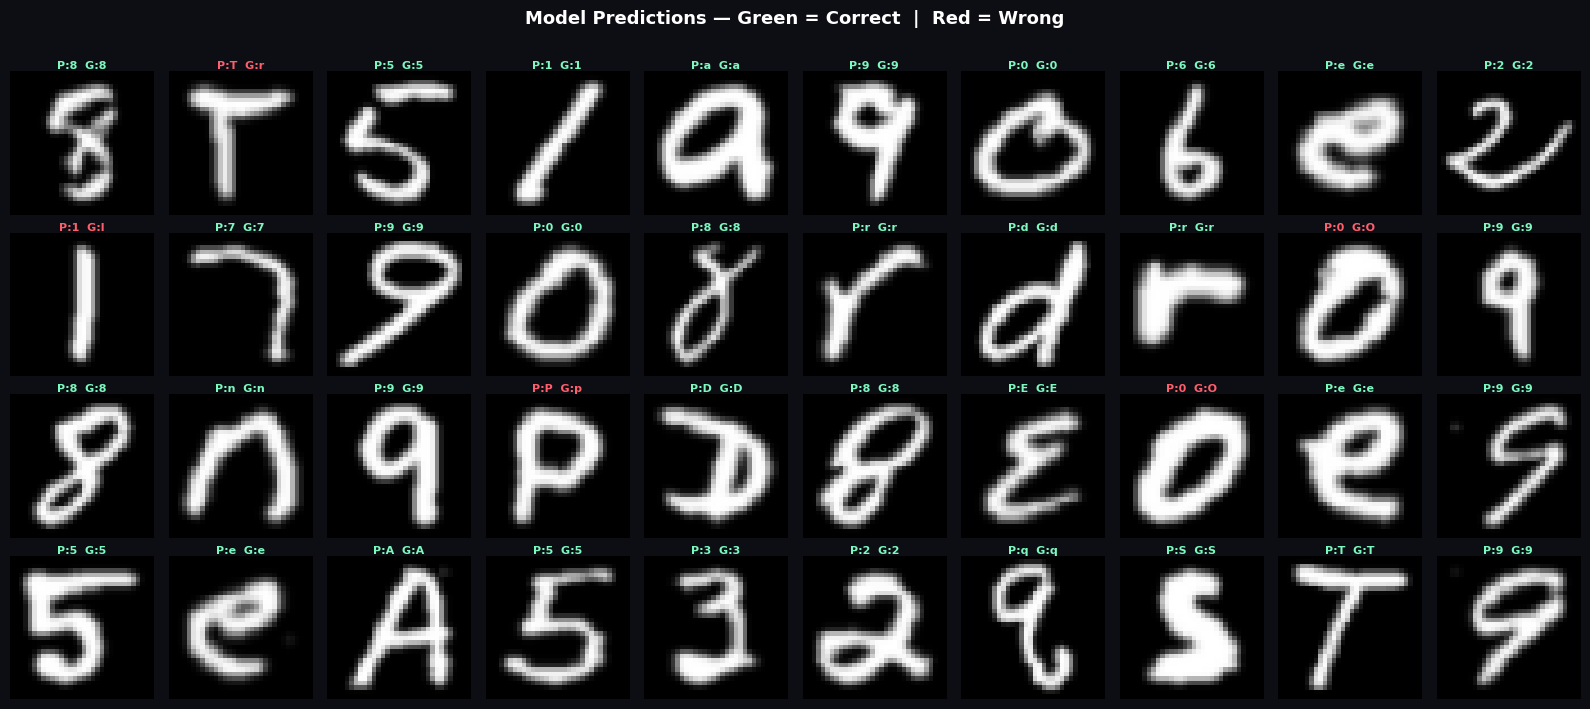

Batch accuracy: 87.5%  (35 correct / 5 wrong out of 40)


In [24]:
# Grab one batch from validation and visualise predictions vs ground truth
imgs, labels, lengths, gt_texts = next(iter(val_dl))

fig, axes = plt.subplots(4, 10, figsize=(16, 7))
fig.patch.set_facecolor('#0d0d14')
fig.suptitle('Model Predictions — Green = Correct  |  Red = Wrong',
             color='white', fontsize=13, fontweight='bold', y=1.01)

correct = wrong = 0
for i, ax in enumerate(axes.flat):
    img_t   = imgs[i].unsqueeze(0)              # (1,1,H,W)
    pred, conf = predict_image(img_t)
    gt      = gt_texts[i]
    is_ok   = (pred == gt)
    correct += is_ok; wrong += not is_ok

    # Display image
    img_np = imgs[i].squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5
    ax.imshow(img_np, cmap='gray', vmin=0, vmax=1)

    color = '#7DF9C0' if is_ok else '#ff5f6d'
    ax.set_title(f'P:{pred}  G:{gt}', color=color,
                 fontsize=8, fontweight='bold', pad=2)
    ax.axis('off')
    for spine in ax.spines.values(): spine.set_edgecolor(color)

batch_acc = correct / (correct + wrong)
plt.tight_layout()
plt.savefig('predictions.png', dpi=120, bbox_inches='tight',
            facecolor='#0d0d14')
plt.show()
print(f'Batch accuracy: {batch_acc*100:.1f}%  ({correct} correct / {wrong} wrong out of {correct+wrong})')

## Cell 13 — Confusion Matrix (Top 20 Classes)

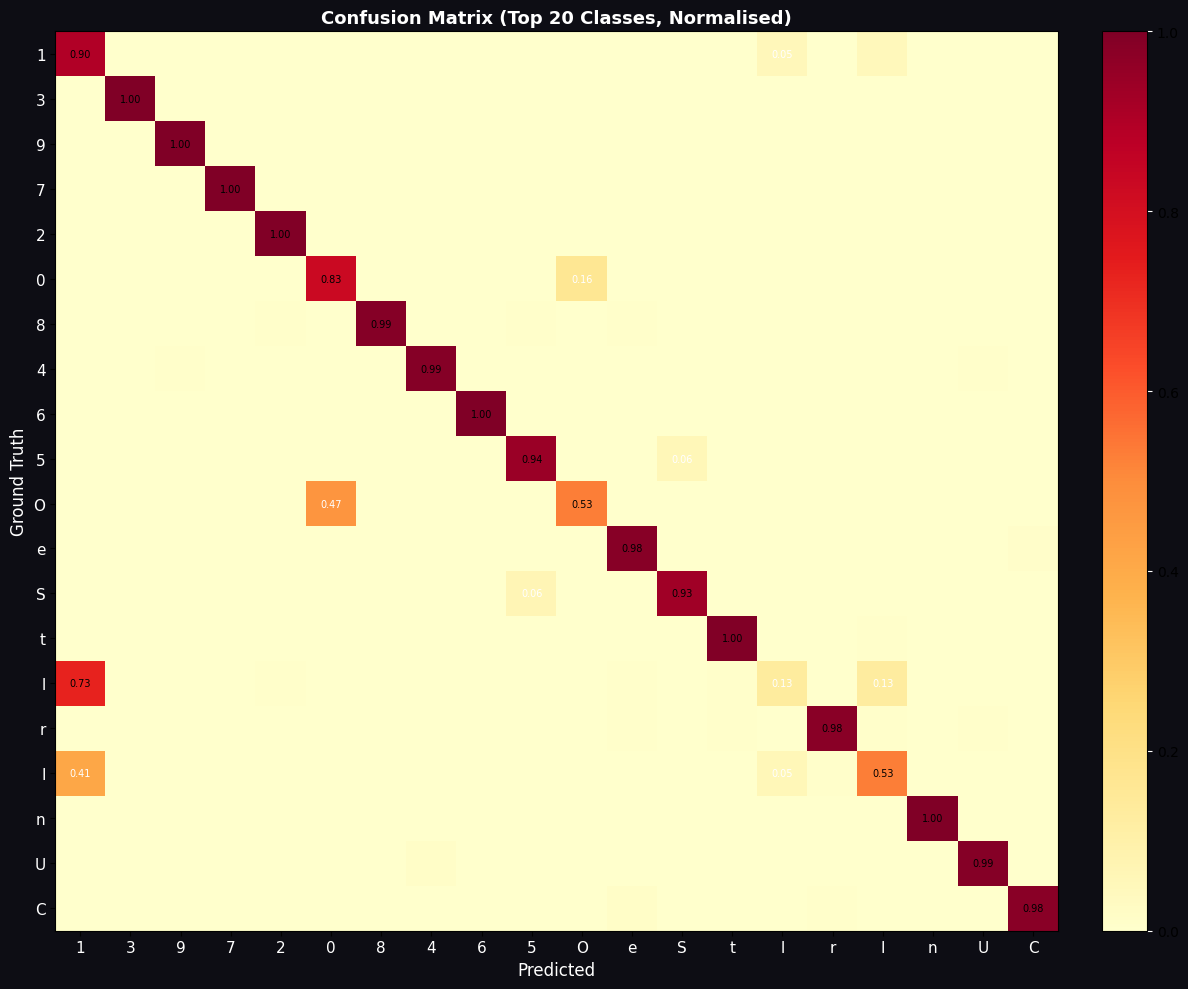

In [25]:
from collections import defaultdict

conf_matrix = defaultdict(lambda: defaultdict(int))

model.eval()
with torch.no_grad():
    for imgs, labels, lengths, gt_texts in tqdm(val_dl, desc='Building confusion matrix', leave=False):
        pred_ids = model(imgs.to(DEVICE)).softmax(2).argmax(2).permute(1,0).cpu()
        for row, gt in zip(pred_ids, gt_texts):
            pred = decode_ctc(row)
            if len(pred) == 1 and len(gt) == 1:
                conf_matrix[gt][pred] += 1

# Top 20 most frequent classes in validation
top_chars = sorted(conf_matrix.keys(),
                   key=lambda c: sum(conf_matrix[c].values()), reverse=True)[:20]

matrix = np.zeros((len(top_chars), len(top_chars)))
for i, gt in enumerate(top_chars):
    for j, pd in enumerate(top_chars):
        matrix[i, j] = conf_matrix[gt].get(pd, 0)

# Normalise rows
row_sums = matrix.sum(axis=1, keepdims=True)
matrix_n = np.divide(matrix, row_sums, where=row_sums > 0)

fig, ax = plt.subplots(figsize=(12, 10))
fig.patch.set_facecolor('#0d0d14')
ax.set_facecolor('#0d0d14')
im = ax.imshow(matrix_n, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).ax.yaxis.set_tick_params(color='white')

ax.set_xticks(range(len(top_chars))); ax.set_xticklabels(top_chars, color='white', fontsize=11)
ax.set_yticks(range(len(top_chars))); ax.set_yticklabels(top_chars, color='white', fontsize=11)
ax.set_xlabel('Predicted', color='white', fontsize=12)
ax.set_ylabel('Ground Truth', color='white', fontsize=12)
ax.set_title('Confusion Matrix (Top 20 Classes, Normalised)',
             color='white', fontsize=13, fontweight='bold')

for i in range(len(top_chars)):
    for j in range(len(top_chars)):
        v = matrix_n[i, j]
        if v > 0.05:
            ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                    color='black' if v > 0.5 else 'white', fontsize=7)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight', facecolor='#0d0d14')
plt.show()

## Cell 14 — Test on Your Own Image 📸

/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_65289/4047925470.py:52: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/j6/pzqtnpsn3jg_xgp4jg2_w4bc0000gn/T/ipykernel_65289/4047925470.py:53: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('inference_result.png', dpi=120, bbox_inches='tight', facecolor='#0d0d14')
/Users/devaguru/ML_Lab/.conda/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


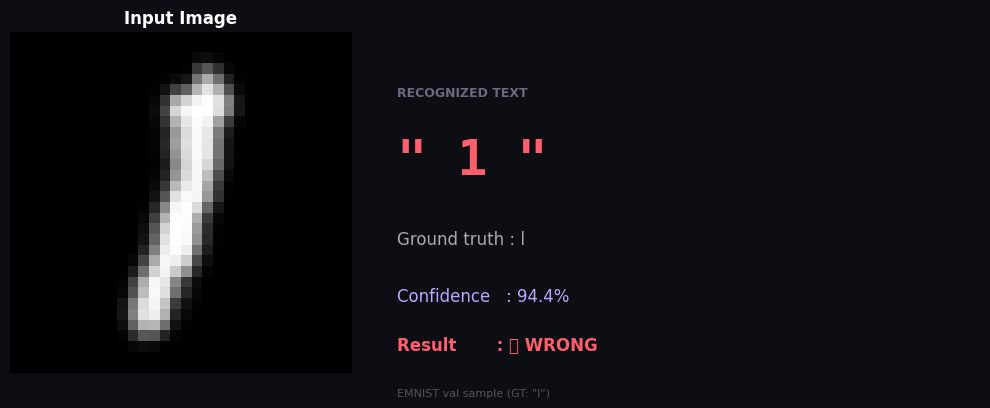


🔎 Predicted : "1"
   GT        : "l"
   Confidence: 94.4%
   Result    : WRONG ❌


In [26]:
# ── Option A: use a validation sample ────────────────────────────────────────
test_img_tensor, _, _, test_gt = val_ds[42]
test_img_tensor = test_img_tensor.unsqueeze(0)   # add batch dim
source_label    = f'EMNIST val sample (GT: "{test_gt}")'

# ── Option B: use your own image file ────────────────────────────────────────
# Uncomment and set the path to your own handwriting image:
#
# MY_IMAGE = 'my_handwriting.png'
# img_pil  = Image.open(MY_IMAGE).convert('L')
# img_pil  = ImageOps.autocontrast(img_pil)
# test_img_tensor = make_transform(False)(img_pil).unsqueeze(0)
# source_label    = f'Your image: {MY_IMAGE}'
# test_gt         = '?'

# ── Predict & Display ─────────────────────────────────────────────────────────
pred_text, confidence = predict_image(test_img_tensor)

fig, axes = plt.subplots(1, 2, figsize=(10, 4),
                          gridspec_kw={'width_ratios': [1, 1.8]})
fig.patch.set_facecolor('#0d0d14')

# Image panel
ax = axes[0]
ax.set_facecolor('#0d0d14')
img_np = test_img_tensor.squeeze().numpy()
img_np = (img_np * 0.5) + 0.5
ax.imshow(img_np, cmap='gray')
ax.set_title('Input Image', color='white', fontsize=12, fontweight='bold')
ax.axis('off')

# Result panel
ax2 = axes[1]
ax2.set_facecolor('#0d0d14')
ax2.axis('off')
is_correct = (pred_text == test_gt)
result_color = '#7DF9C0' if is_correct else '#ff5f6d'

ax2.text(0.05, 0.80, 'RECOGNIZED TEXT', transform=ax2.transAxes,
         color='#6b6a80', fontsize=9, fontweight='bold')
ax2.text(0.05, 0.58, f'" {pred_text} "', transform=ax2.transAxes,
         color=result_color, fontsize=36, fontweight='bold', fontfamily='monospace')
ax2.text(0.05, 0.38, f'Ground truth : {test_gt}', transform=ax2.transAxes,
         color='#aaa', fontsize=12)
ax2.text(0.05, 0.22, f'Confidence   : {confidence*100:.1f}%', transform=ax2.transAxes,
         color='#B8A9FF', fontsize=12)
ax2.text(0.05, 0.08, f'Result       : {"✅ CORRECT" if is_correct else "❌ WRONG"}',
         transform=ax2.transAxes, color=result_color, fontsize=12, fontweight='bold')
ax2.text(0.05, -0.05, source_label, transform=ax2.transAxes,
         color='#555', fontsize=8)

plt.tight_layout()
plt.savefig('inference_result.png', dpi=120, bbox_inches='tight', facecolor='#0d0d14')
plt.show()

print(f'\n🔎 Predicted : "{pred_text}"')
print(f'   GT        : "{test_gt}"')
print(f'   Confidence: {confidence*100:.1f}%')
print(f'   Result    : {"CORRECT ✅" if is_correct else "WRONG ❌"}')

## Cell 15 — Final Summary Report

In [27]:
print('=' * 60)
print('   CRNN HANDWRITING RECOGNITION — FINAL REPORT')
print('=' * 60)
print(f'   Dataset       : EMNIST ByClass (62 classes)')
print(f'   Train samples : {len(train_ds):,}')
print(f'   Val   samples : {len(val_ds):,}')
print(f'   Model params  : {sum(p.numel() for p in model.parameters()):,}')
print(f'   Epochs        : {EPOCHS}')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Optimizer     : AdamW  lr={LR}')
print(f'   Scheduler     : CosineAnnealing')
print(f'   Device        : {DEVICE}')
print('─' * 60)
print(f'   Best Accuracy : {max(history["acc"])*100:.2f}%')
print(f'   Final CER     : {history["cer"][-1]:.4f}')
print(f'   Final Val Loss: {history["va_loss"][-1]:.4f}')
print('─' * 60)
print('   Saved files:')
print(f'     checkpoints/best_crnn.pth  ← trained model')
print(f'     sample_images.png')
print(f'     training_curves.png')
print(f'     predictions.png')
print(f'     confusion_matrix.png')
print(f'     inference_result.png')
print('=' * 60)

   CRNN HANDWRITING RECOGNITION — FINAL REPORT
   Dataset       : EMNIST ByClass (62 classes)
   Train samples : 60,000
   Val   samples : 10,000
   Model params  : 8,344,319
   Epochs        : 15
   Batch size    : 128
   Optimizer     : AdamW  lr=0.0003
   Scheduler     : CosineAnnealing
   Device        : mps
────────────────────────────────────────────────────────────
   Best Accuracy : 85.79%
   Final CER     : 0.1429
   Final Val Loss: 0.3790
────────────────────────────────────────────────────────────
   Saved files:
     checkpoints/best_crnn.pth  ← trained model
     sample_images.png
     training_curves.png
     predictions.png
     confusion_matrix.png
     inference_result.png


# Images Testing


In [28]:
from torchvision import datasets

val_ds = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=True
)

100%|██████████| 562M/562M [00:14<00:00, 38.6MB/s]


In [29]:
import os

TEST_FOLDER = "test_images"
os.makedirs(TEST_FOLDER, exist_ok=True)

In [31]:
import os
from torchvision import datasets

TEST_FOLDER = "test_images"
os.makedirs(TEST_FOLDER, exist_ok=True)

# Load EMNIST
val_ds = datasets.EMNIST(
    root="data",
    split="letters",
    train=False,
    download=False
)

# Export images
for i in range(200):

    img, label = val_ds[i]   # img is already a PIL image

    save_path = os.path.join(TEST_FOLDER, f"emnist_{i}_label_{label}.png")

    img.save(save_path)

print("✅ Images saved to:", TEST_FOLDER)

✅ Images saved to: test_images


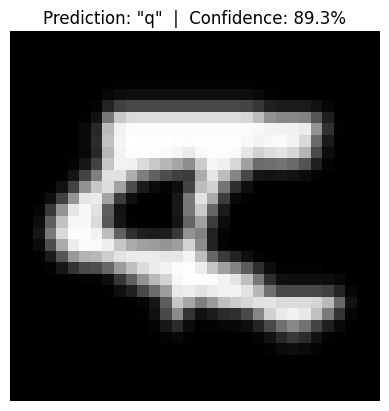

Image       : emnist_50_label_1.png
Prediction  : q
Confidence  : 89.3%
-----------------------------


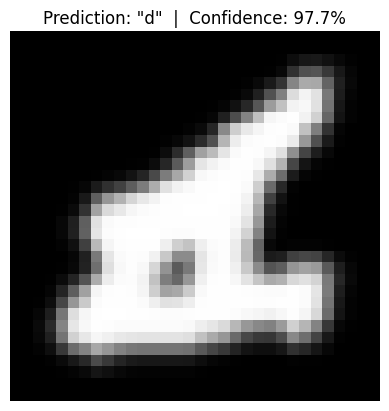

Image       : emnist_20_label_1.png
Prediction  : d
Confidence  : 97.7%
-----------------------------


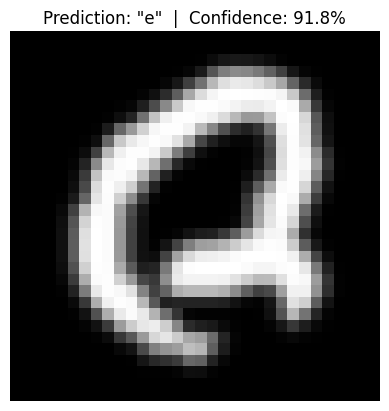

Image       : emnist_83_label_1.png
Prediction  : e
Confidence  : 91.8%
-----------------------------


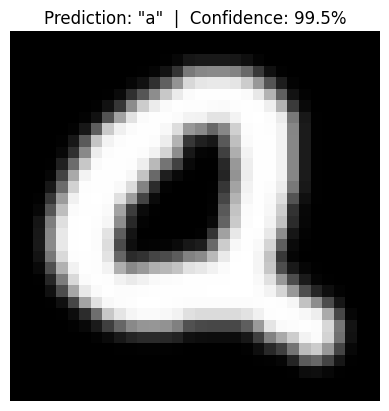

Image       : emnist_105_label_1.png
Prediction  : a
Confidence  : 99.5%
-----------------------------


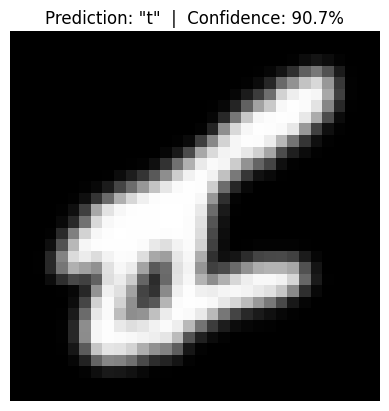

Image       : emnist_188_label_1.png
Prediction  : t
Confidence  : 90.7%
-----------------------------


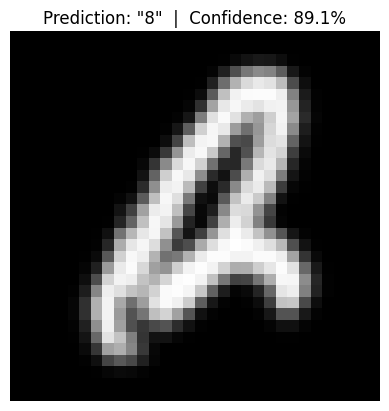

Image       : emnist_175_label_1.png
Prediction  : 8
Confidence  : 89.1%
-----------------------------


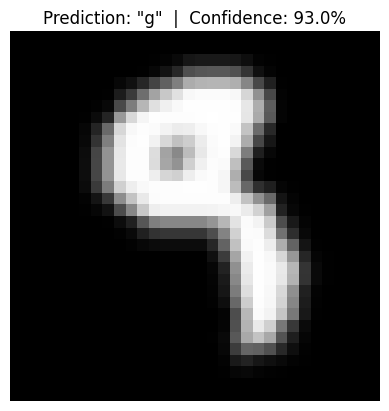

Image       : emnist_169_label_1.png
Prediction  : g
Confidence  : 93.0%
-----------------------------


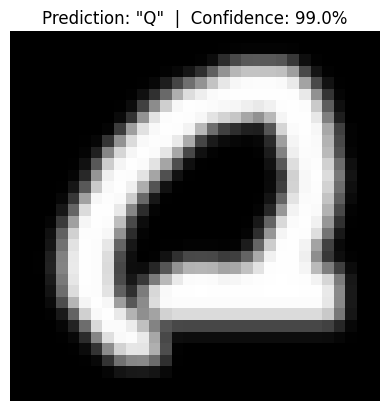

Image       : emnist_12_label_1.png
Prediction  : Q
Confidence  : 99.0%
-----------------------------


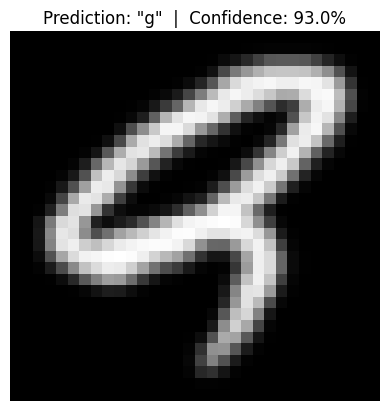

Image       : emnist_194_label_1.png
Prediction  : g
Confidence  : 93.0%
-----------------------------


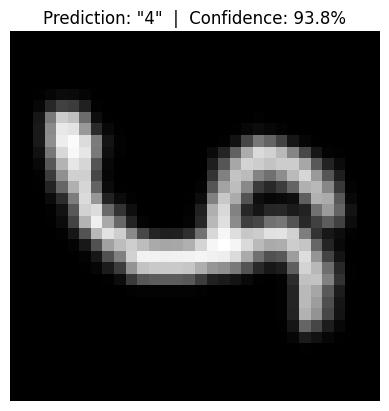

Image       : emnist_119_label_1.png
Prediction  : 4
Confidence  : 93.8%
-----------------------------


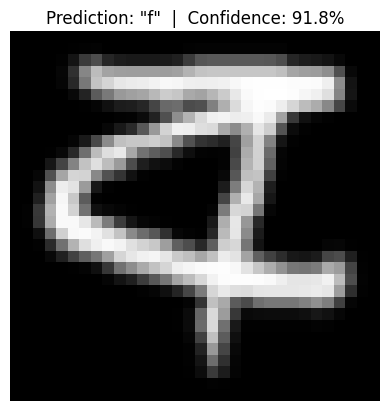

Image       : emnist_62_label_1.png
Prediction  : f
Confidence  : 91.8%
-----------------------------


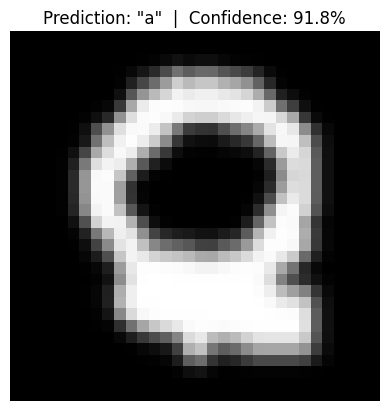

Image       : emnist_147_label_1.png
Prediction  : a
Confidence  : 91.8%
-----------------------------


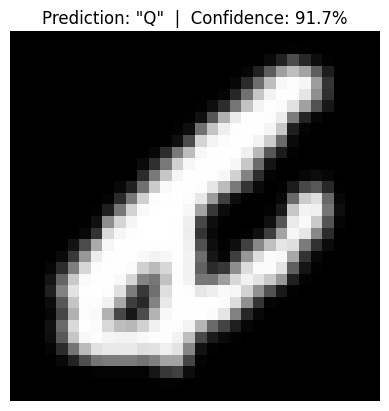

Image       : emnist_137_label_1.png
Prediction  : Q
Confidence  : 91.7%
-----------------------------


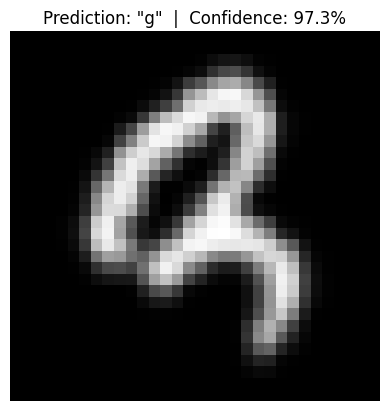

Image       : emnist_29_label_1.png
Prediction  : g
Confidence  : 97.3%
-----------------------------


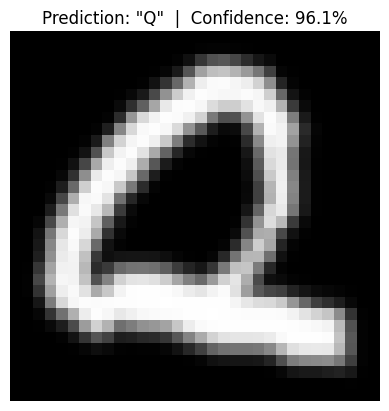

Image       : emnist_152_label_1.png
Prediction  : Q
Confidence  : 96.1%
-----------------------------


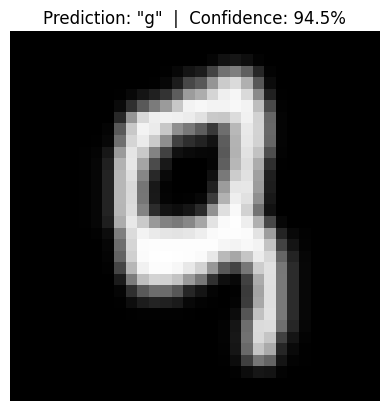

Image       : emnist_6_label_1.png
Prediction  : g
Confidence  : 94.5%
-----------------------------


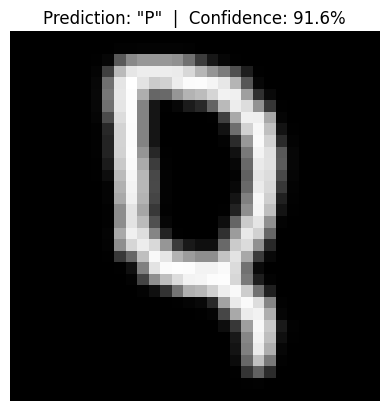

Image       : emnist_59_label_1.png
Prediction  : P
Confidence  : 91.6%
-----------------------------


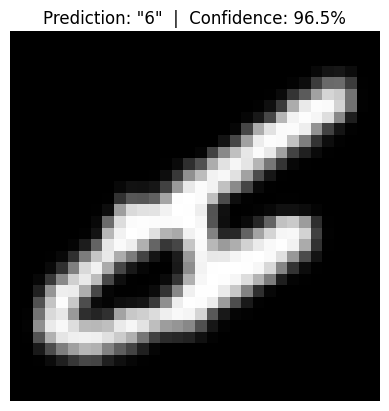

Image       : emnist_122_label_1.png
Prediction  : 6
Confidence  : 96.5%
-----------------------------


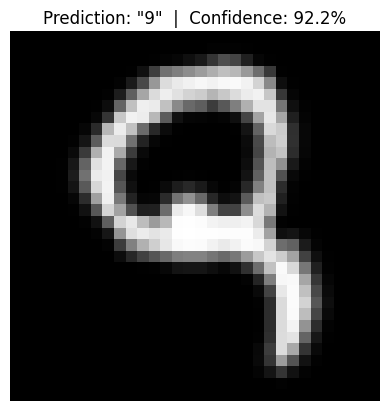

Image       : emnist_181_label_1.png
Prediction  : 9
Confidence  : 92.2%
-----------------------------


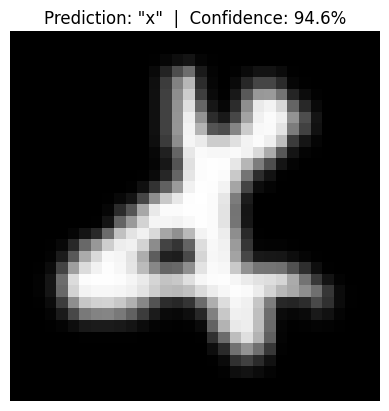

Image       : emnist_77_label_1.png
Prediction  : x
Confidence  : 94.6%
-----------------------------


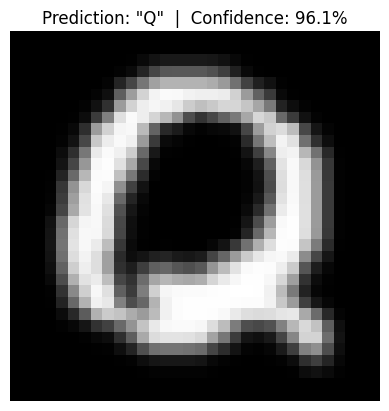

Image       : emnist_96_label_1.png
Prediction  : Q
Confidence  : 96.1%
-----------------------------


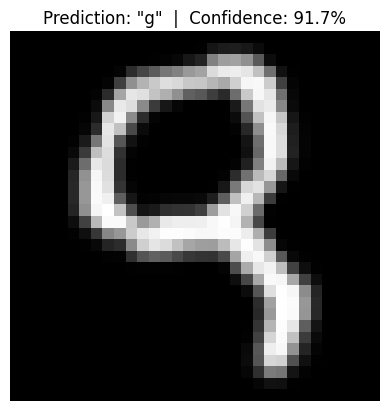

Image       : emnist_110_label_1.png
Prediction  : g
Confidence  : 91.7%
-----------------------------


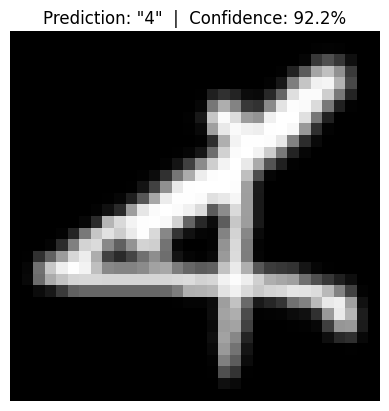

Image       : emnist_160_label_1.png
Prediction  : 4
Confidence  : 92.2%
-----------------------------


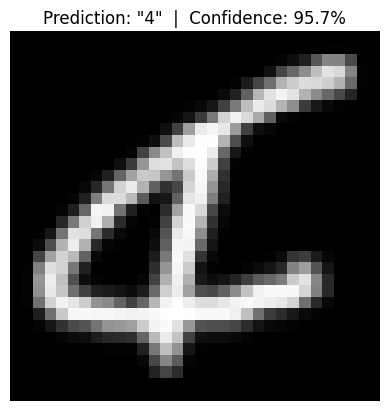

Image       : emnist_45_label_1.png
Prediction  : 4
Confidence  : 95.7%
-----------------------------


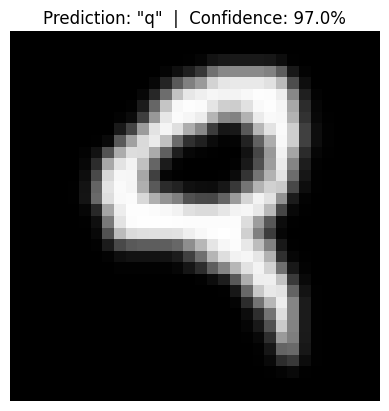

Image       : emnist_35_label_1.png
Prediction  : q
Confidence  : 97.0%
-----------------------------


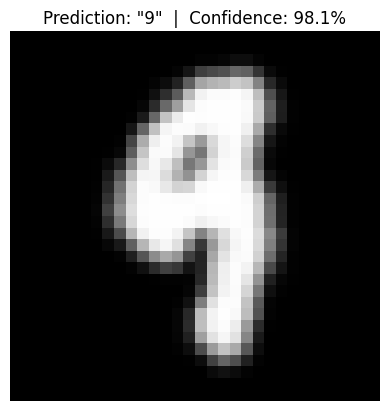

Image       : emnist_109_label_1.png
Prediction  : 9
Confidence  : 98.1%
-----------------------------


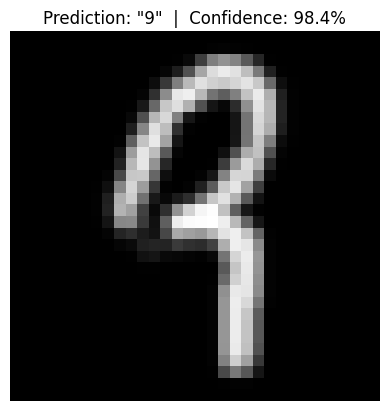

Image       : emnist_72_label_1.png
Prediction  : 9
Confidence  : 98.4%
-----------------------------


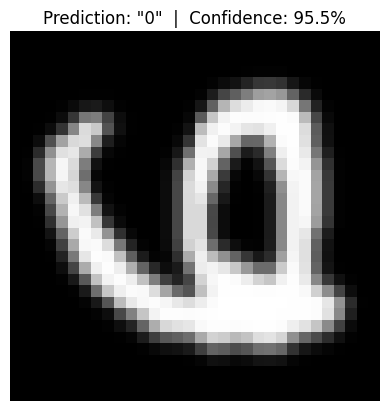

Image       : emnist_184_label_1.png
Prediction  : 0
Confidence  : 95.5%
-----------------------------


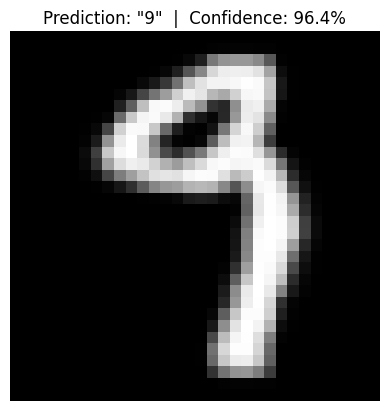

Image       : emnist_179_label_1.png
Prediction  : 9
Confidence  : 96.4%
-----------------------------


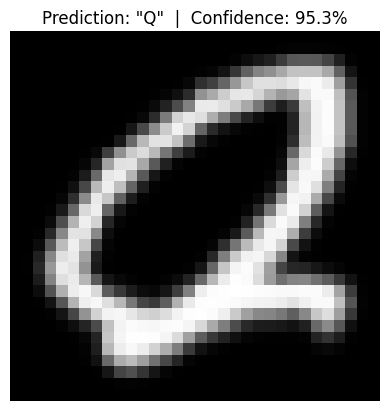

Image       : emnist_3_label_1.png
Prediction  : Q
Confidence  : 95.3%
-----------------------------


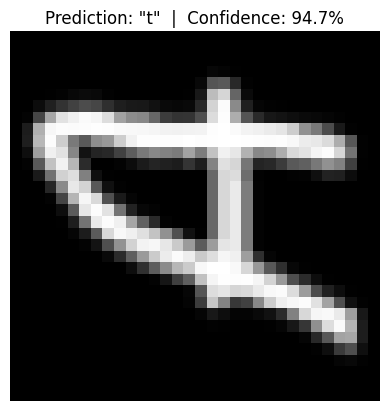

Image       : emnist_127_label_1.png
Prediction  : t
Confidence  : 94.7%
-----------------------------


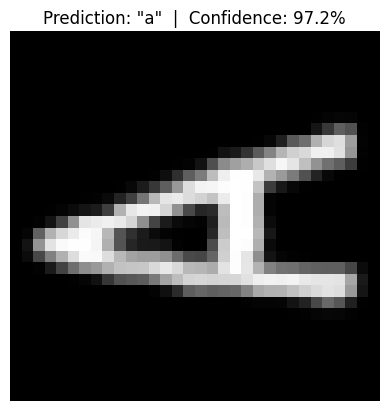

Image       : emnist_157_label_1.png
Prediction  : a
Confidence  : 97.2%
-----------------------------


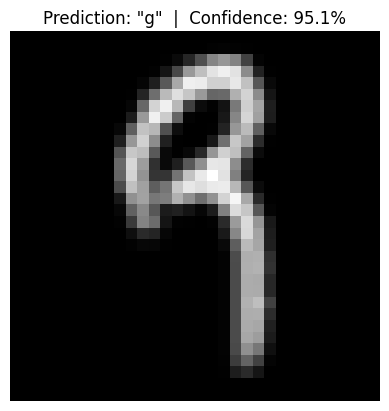

Image       : emnist_30_label_1.png
Prediction  : g
Confidence  : 95.1%
-----------------------------


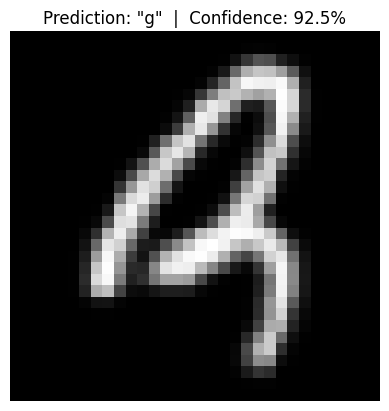

Image       : emnist_40_label_1.png
Prediction  : g
Confidence  : 92.5%
-----------------------------


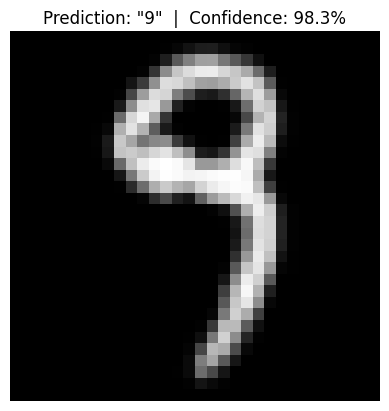

Image       : emnist_165_label_1.png
Prediction  : 9
Confidence  : 98.3%
-----------------------------


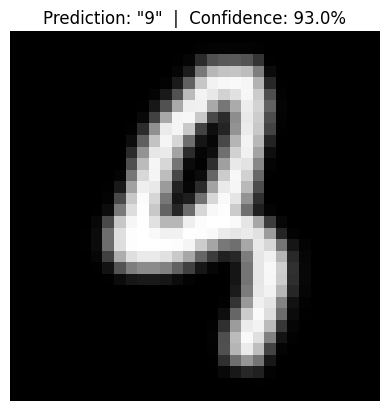

Image       : emnist_198_label_1.png
Prediction  : 9
Confidence  : 93.0%
-----------------------------


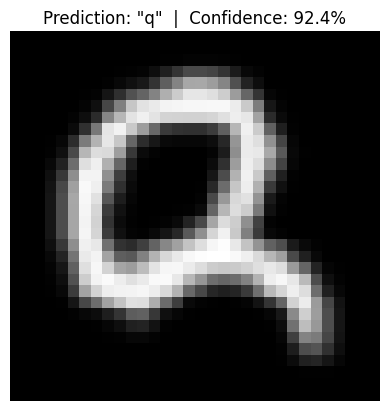

Image       : emnist_115_label_1.png
Prediction  : q
Confidence  : 92.4%
-----------------------------


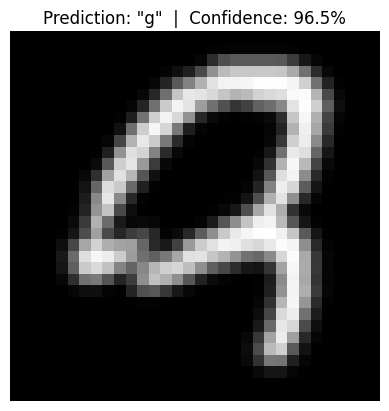

Image       : emnist_93_label_1.png
Prediction  : g
Confidence  : 96.5%
-----------------------------


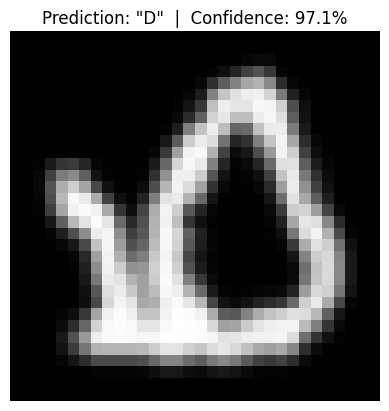

Image       : emnist_170_label_1.png
Prediction  : D
Confidence  : 97.1%
-----------------------------


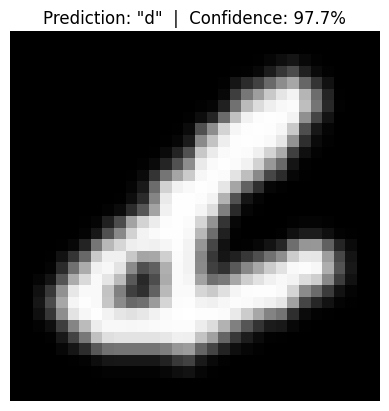

Image       : emnist_100_label_1.png
Prediction  : d
Confidence  : 97.7%
-----------------------------


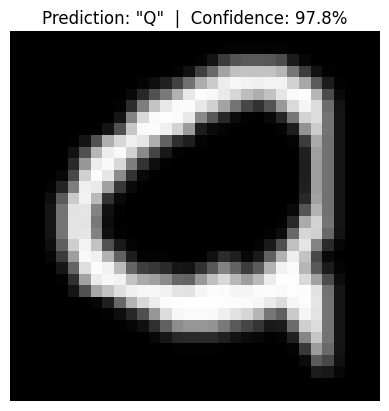

Image       : emnist_86_label_1.png
Prediction  : Q
Confidence  : 97.8%
-----------------------------


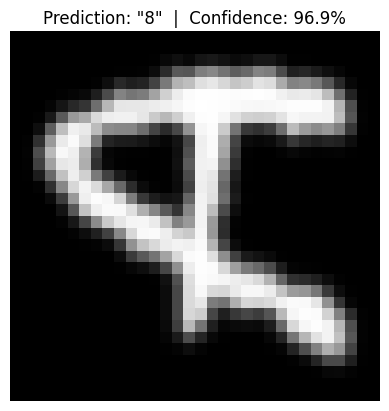

Image       : emnist_25_label_1.png
Prediction  : 8
Confidence  : 96.9%
-----------------------------


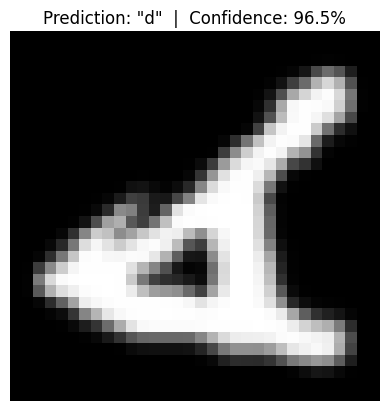

Image       : emnist_55_label_1.png
Prediction  : d
Confidence  : 96.5%
-----------------------------


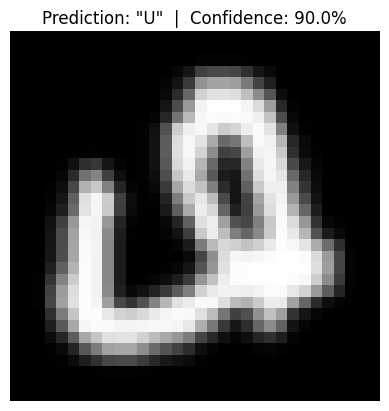

Image       : emnist_49_label_1.png
Prediction  : U
Confidence  : 90.0%
-----------------------------


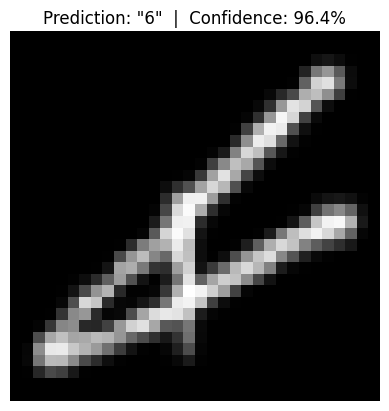

Image       : emnist_132_label_1.png
Prediction  : 6
Confidence  : 96.4%
-----------------------------


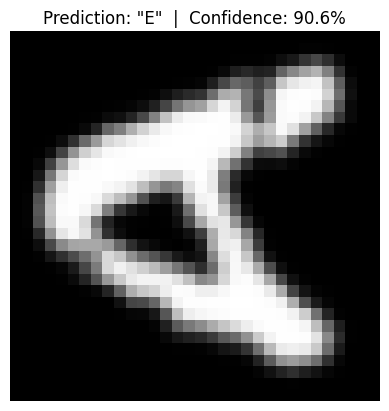

Image       : emnist_39_label_1.png
Prediction  : E
Confidence  : 90.6%
-----------------------------


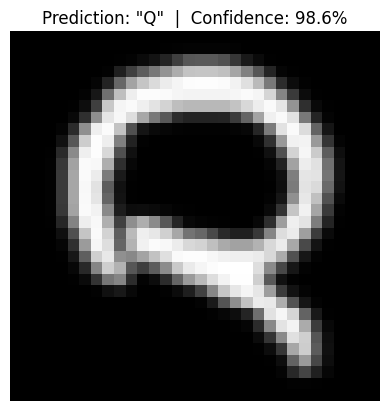

Image       : emnist_142_label_1.png
Prediction  : Q
Confidence  : 98.6%
-----------------------------


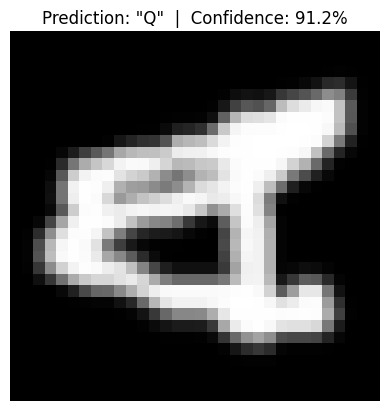

Image       : emnist_67_label_1.png
Prediction  : Q
Confidence  : 91.2%
-----------------------------


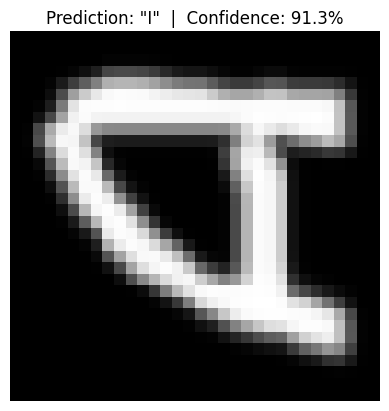

Image       : emnist_191_label_1.png
Prediction  : I
Confidence  : 91.3%
-----------------------------


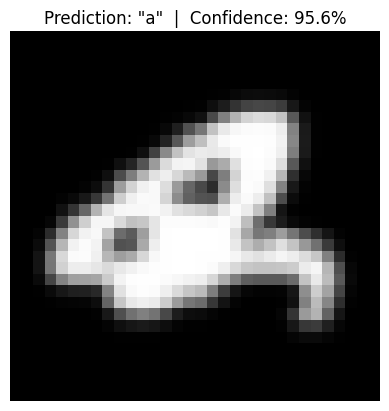

Image       : emnist_17_label_1.png
Prediction  : a
Confidence  : 95.6%
-----------------------------


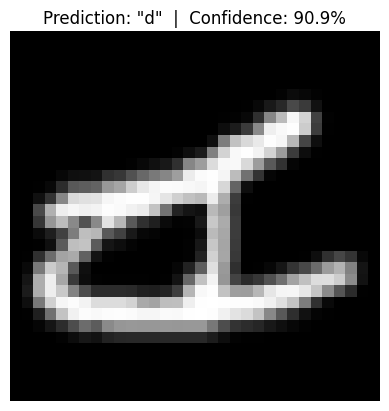

Image       : emnist_64_label_1.png
Prediction  : d
Confidence  : 90.9%
-----------------------------


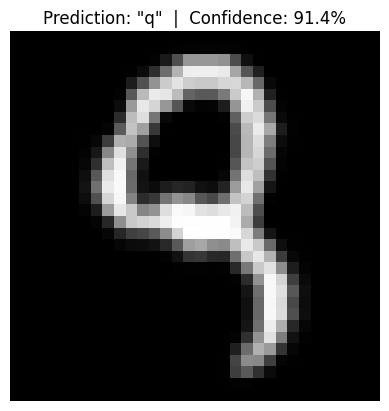

Image       : emnist_99_label_1.png
Prediction  : q
Confidence  : 91.4%
-----------------------------


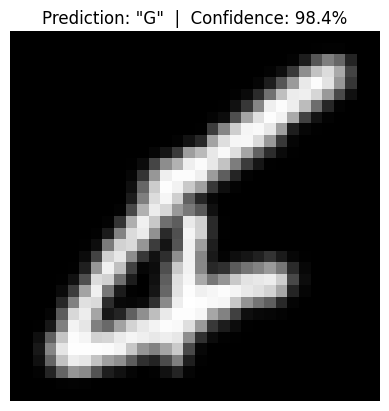

Image       : emnist_14_label_1.png
Prediction  : G
Confidence  : 98.4%
-----------------------------


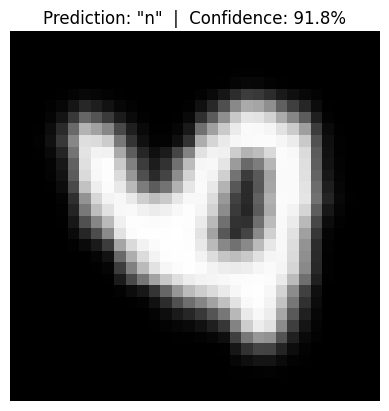

Image       : emnist_192_label_1.png
Prediction  : n
Confidence  : 91.8%
-----------------------------


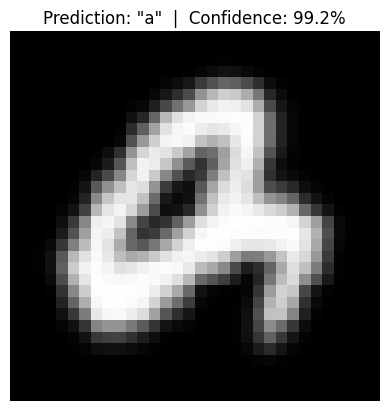

Image       : emnist_131_label_1.png
Prediction  : a
Confidence  : 99.2%
-----------------------------


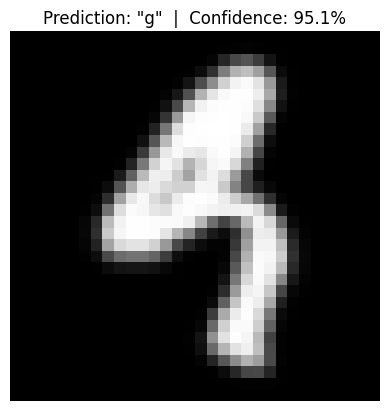

Image       : emnist_141_label_1.png
Prediction  : g
Confidence  : 95.1%
-----------------------------


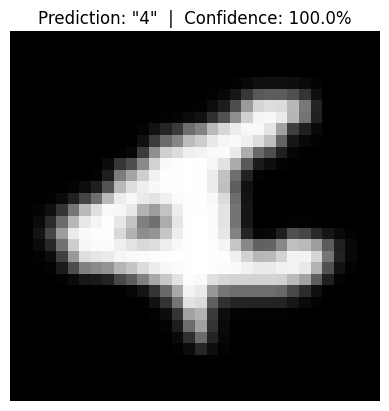

Image       : emnist_26_label_1.png
Prediction  : 4
Confidence  : 100.0%
-----------------------------


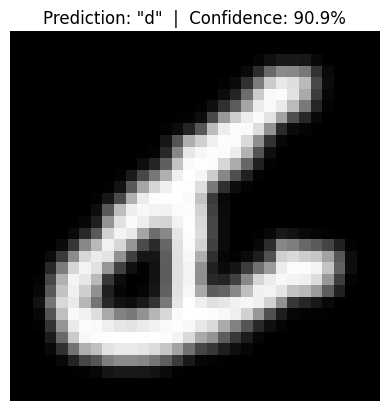

Image       : emnist_56_label_1.png
Prediction  : d
Confidence  : 90.9%
-----------------------------


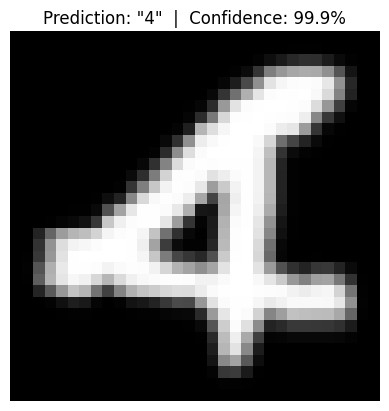

Image       : emnist_9_label_1.png
Prediction  : 4
Confidence  : 99.9%
-----------------------------


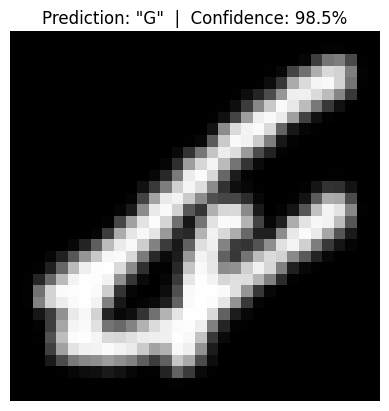

Image       : emnist_173_label_1.png
Prediction  : G
Confidence  : 98.5%
-----------------------------


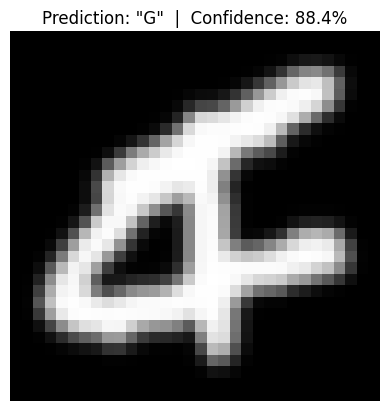

Image       : emnist_85_label_1.png
Prediction  : G
Confidence  : 88.4%
-----------------------------


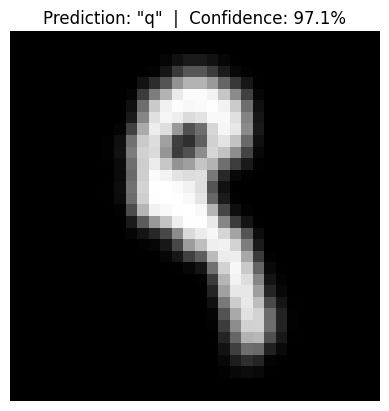

Image       : emnist_103_label_1.png
Prediction  : q
Confidence  : 97.1%
-----------------------------


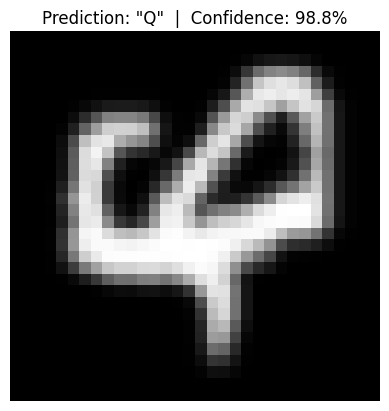

Image       : emnist_78_label_1.png
Prediction  : Q
Confidence  : 98.8%
-----------------------------


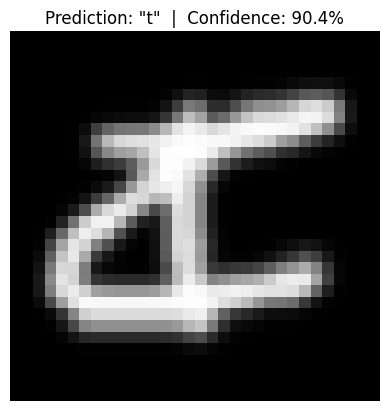

Image       : emnist_166_label_1.png
Prediction  : t
Confidence  : 90.4%
-----------------------------


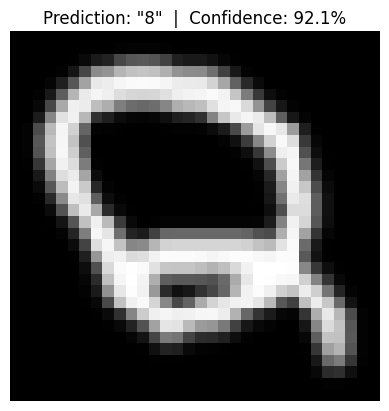

Image       : emnist_90_label_1.png
Prediction  : 8
Confidence  : 92.1%
-----------------------------


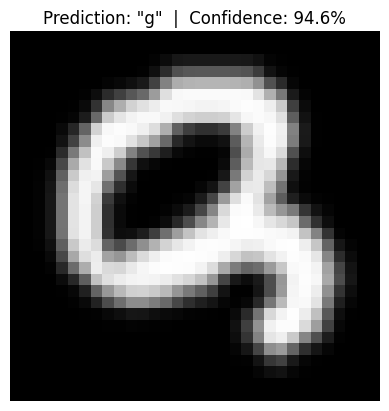

Image       : emnist_116_label_1.png
Prediction  : g
Confidence  : 94.6%
-----------------------------


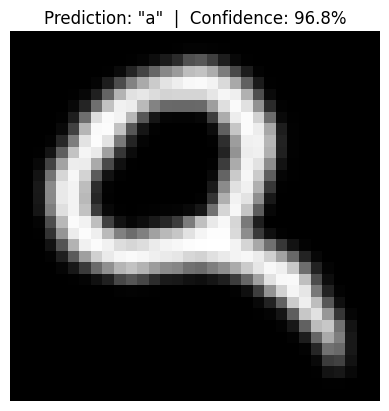

Image       : emnist_33_label_1.png
Prediction  : a
Confidence  : 96.8%
-----------------------------


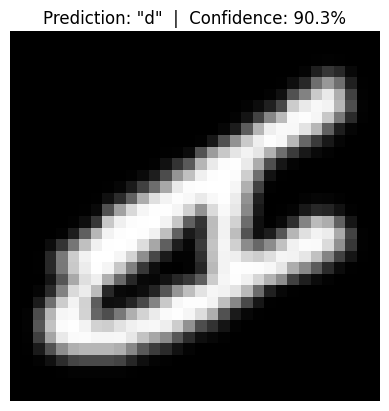

Image       : emnist_148_label_1.png
Prediction  : d
Confidence  : 90.3%
-----------------------------


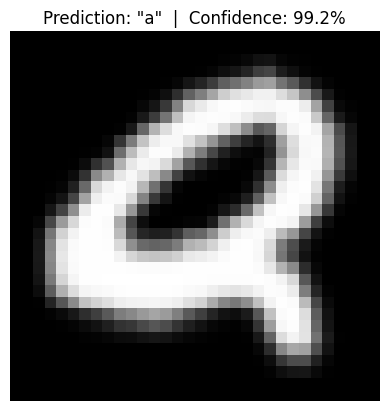

Image       : emnist_43_label_1.png
Prediction  : a
Confidence  : 99.2%
-----------------------------


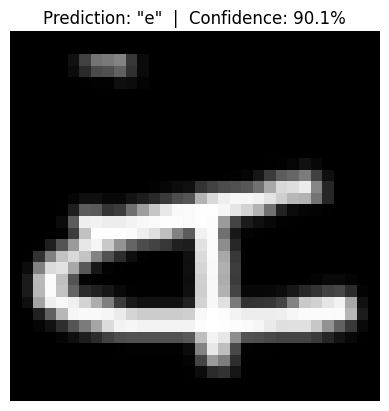

Image       : emnist_138_label_1.png
Prediction  : e
Confidence  : 90.1%
-----------------------------


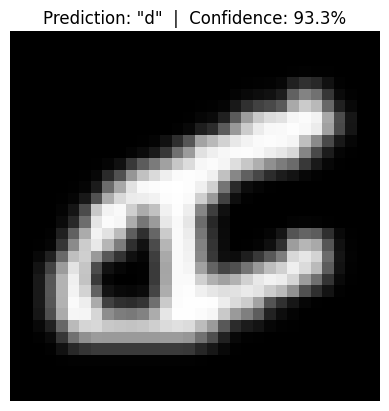

Image       : emnist_124_label_1.png
Prediction  : d
Confidence  : 93.3%
-----------------------------


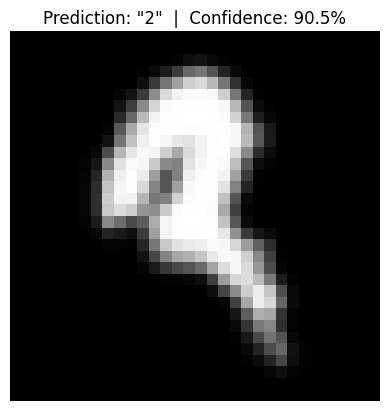

Image       : emnist_0_label_1.png
Prediction  : 2
Confidence  : 90.5%
-----------------------------


Exception ignored in: <function tqdm.__del__ at 0x13992f920>
Traceback (most recent call last):
  File "/Users/devaguru/ML_Lab/.conda/lib/python3.11/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/Users/devaguru/ML_Lab/.conda/lib/python3.11/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
    ^^^^^^^^^
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


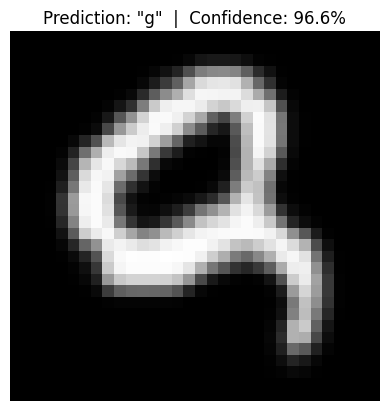

Image       : emnist_154_label_1.png
Prediction  : g
Confidence  : 96.6%
-----------------------------


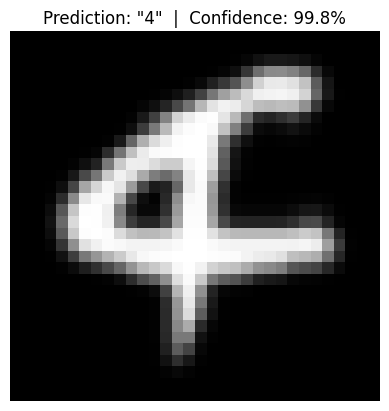

Image       : emnist_71_label_1.png
Prediction  : 4
Confidence  : 99.8%
-----------------------------


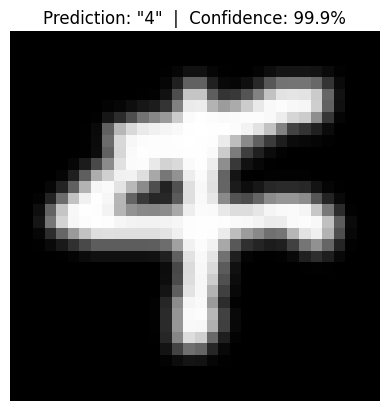

Image       : emnist_187_label_1.png
Prediction  : 4
Confidence  : 99.9%
-----------------------------


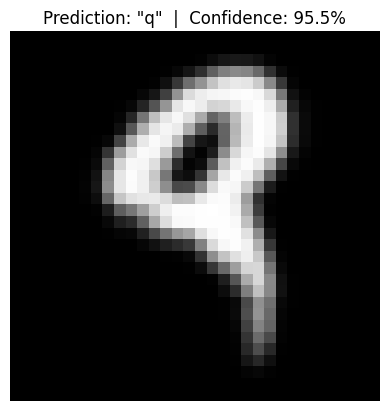

Image       : emnist_46_label_1.png
Prediction  : q
Confidence  : 95.5%
-----------------------------


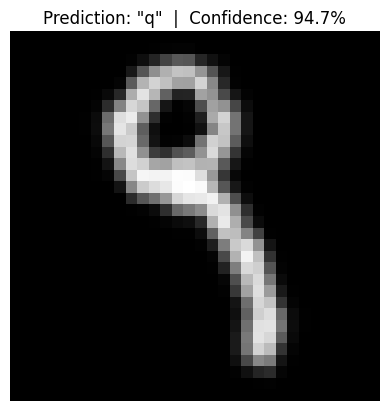

Image       : emnist_36_label_1.png
Prediction  : q
Confidence  : 94.7%
-----------------------------


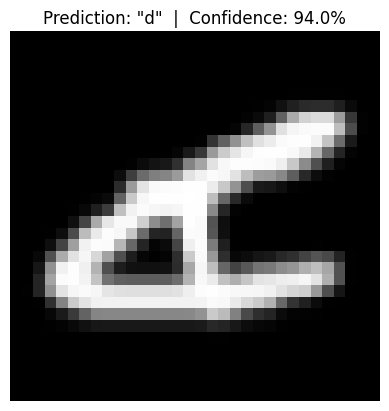

Image       : emnist_113_label_1.png
Prediction  : d
Confidence  : 94.0%
-----------------------------


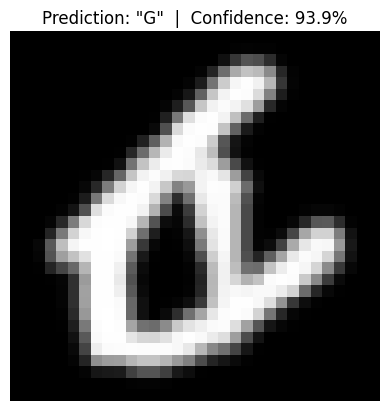

Image       : emnist_68_label_1.png
Prediction  : G
Confidence  : 93.9%
-----------------------------


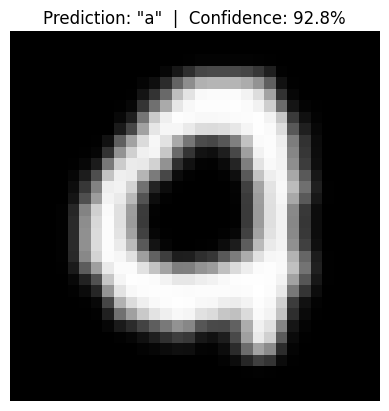

Image       : emnist_95_label_1.png
Prediction  : a
Confidence  : 92.8%
-----------------------------


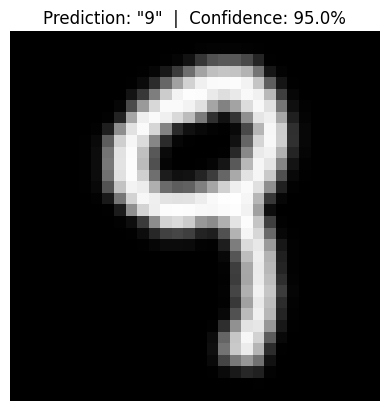

Image       : emnist_163_label_1.png
Prediction  : 9
Confidence  : 95.0%
-----------------------------


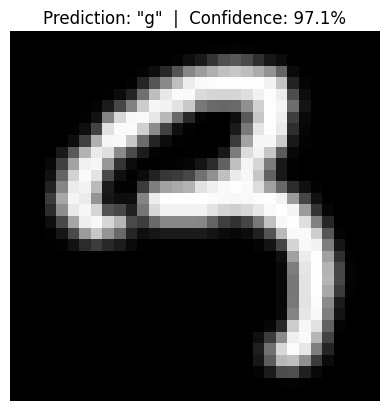

Image       : emnist_18_label_1.png
Prediction  : g
Confidence  : 97.1%
-----------------------------


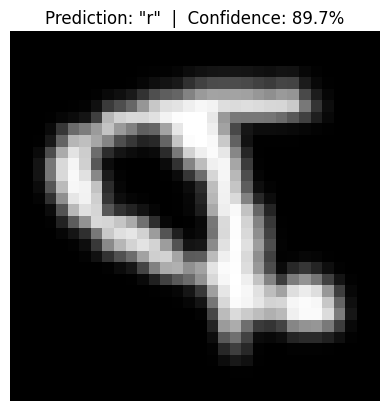

Image       : emnist_182_label_1.png
Prediction  : r
Confidence  : 89.7%
-----------------------------


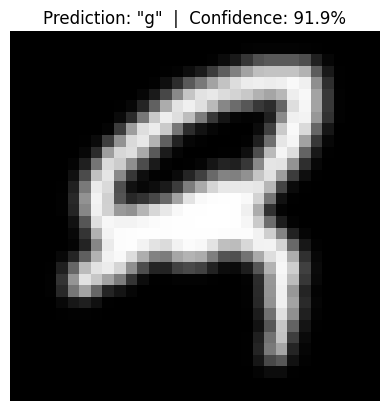

Image       : emnist_89_label_1.png
Prediction  : g
Confidence  : 91.9%
-----------------------------


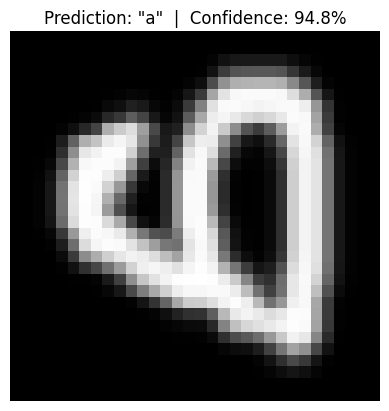

Image       : emnist_74_label_1.png
Prediction  : a
Confidence  : 94.8%
-----------------------------


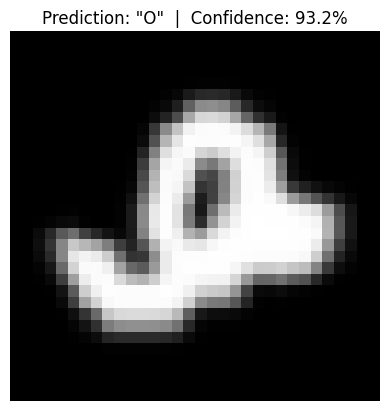

Image       : emnist_151_label_1.png
Prediction  : O
Confidence  : 93.2%
-----------------------------


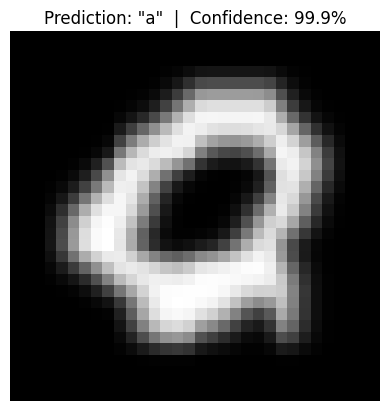

Image       : emnist_121_label_1.png
Prediction  : a
Confidence  : 99.9%
-----------------------------


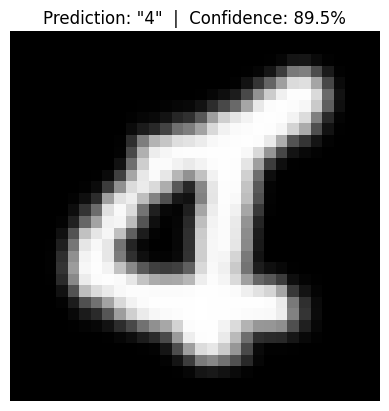

Image       : emnist_5_label_1.png
Prediction  : 4
Confidence  : 89.5%
-----------------------------


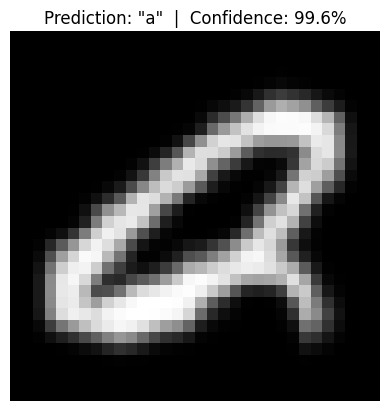

Image       : emnist_144_label_1.png
Prediction  : a
Confidence  : 99.6%
-----------------------------


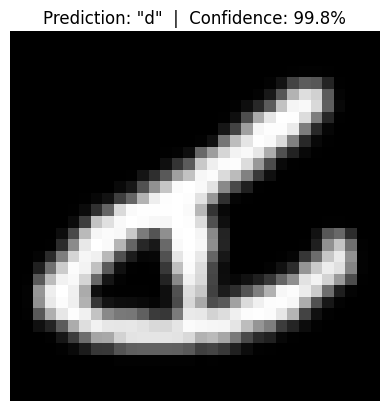

Image       : emnist_134_label_1.png
Prediction  : d
Confidence  : 99.8%
-----------------------------


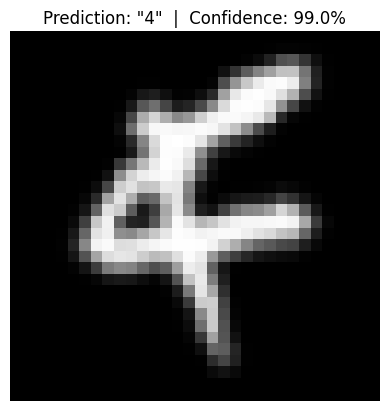

Image       : emnist_197_label_1.png
Prediction  : 4
Confidence  : 99.0%
-----------------------------


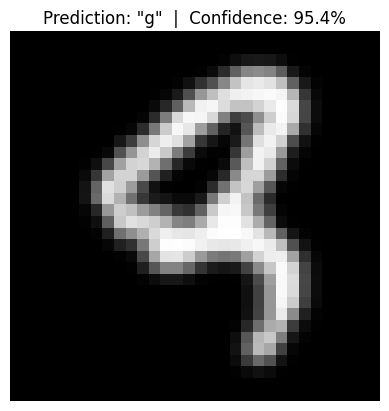

Image       : emnist_11_label_1.png
Prediction  : g
Confidence  : 95.4%
-----------------------------


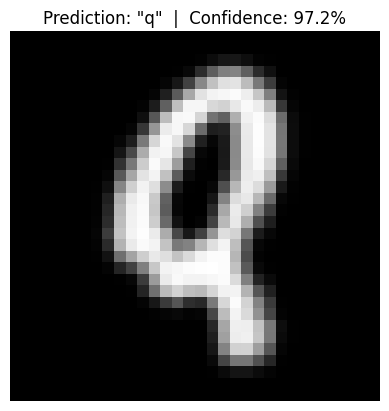

Image       : emnist_61_label_1.png
Prediction  : q
Confidence  : 97.2%
-----------------------------


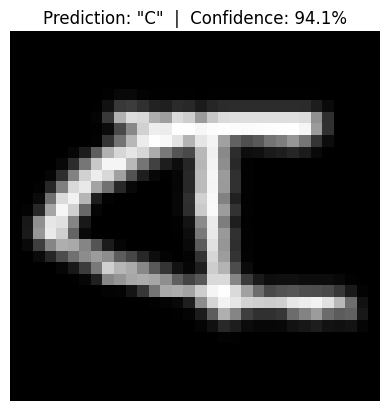

Image       : emnist_106_label_1.png
Prediction  : C
Confidence  : 94.1%
-----------------------------


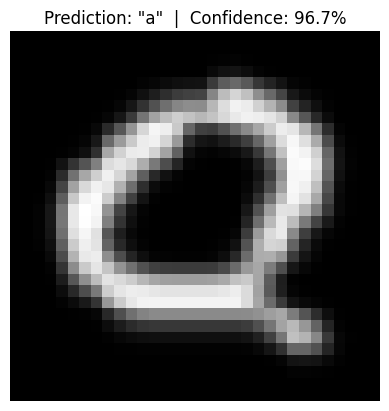

Image       : emnist_80_label_1.png
Prediction  : a
Confidence  : 96.7%
-----------------------------


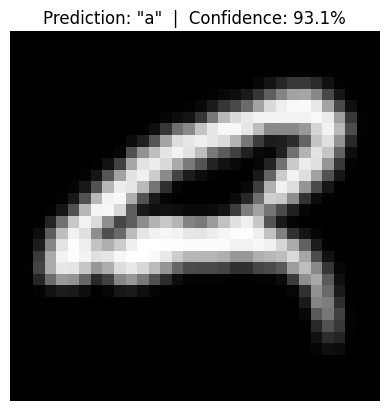

Image       : emnist_176_label_1.png
Prediction  : a
Confidence  : 93.1%
-----------------------------


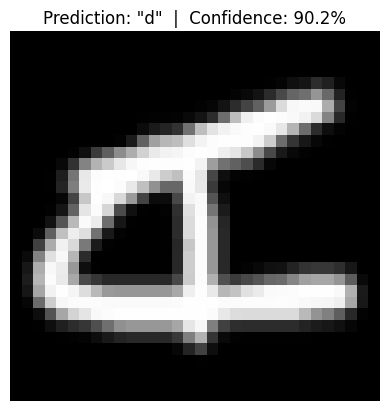

Image       : emnist_53_label_1.png
Prediction  : d
Confidence  : 90.2%
-----------------------------


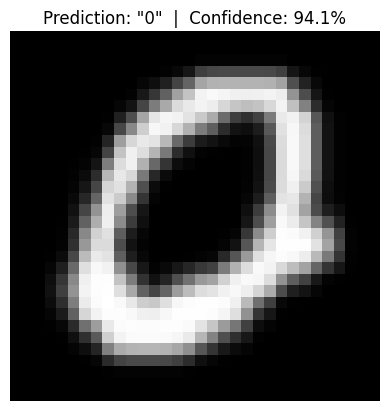

Image       : emnist_128_label_1.png
Prediction  : 0
Confidence  : 94.1%
-----------------------------


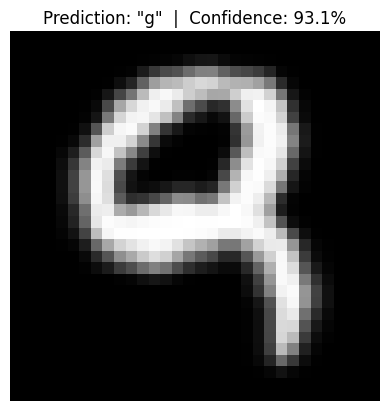

Image       : emnist_23_label_1.png
Prediction  : g
Confidence  : 93.1%
-----------------------------


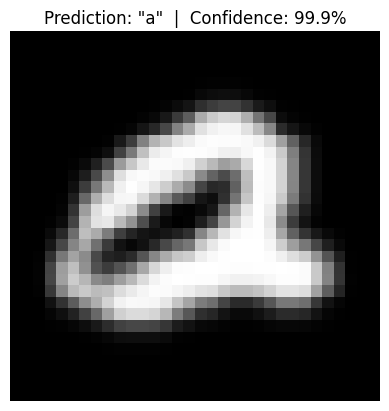

Image       : emnist_158_label_1.png
Prediction  : a
Confidence  : 99.9%
-----------------------------


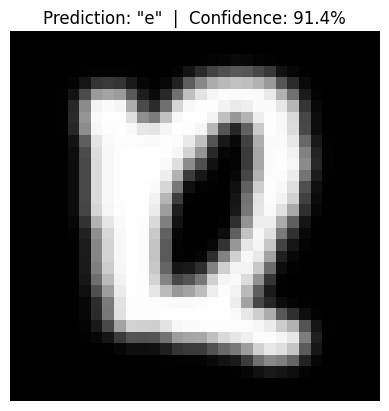

Image       : emnist_143_label_1.png
Prediction  : e
Confidence  : 91.4%
-----------------------------


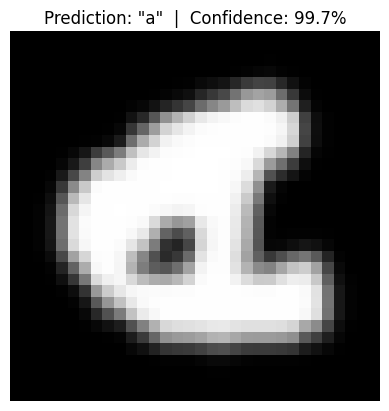

Image       : emnist_38_label_1.png
Prediction  : a
Confidence  : 99.7%
-----------------------------


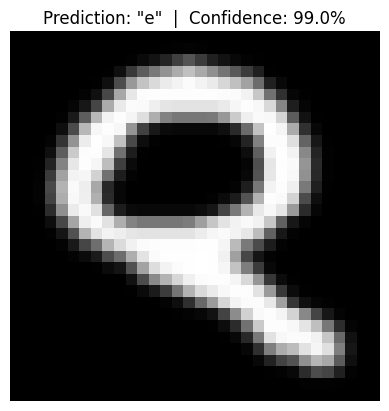

Image       : emnist_133_label_1.png
Prediction  : e
Confidence  : 99.0%
-----------------------------


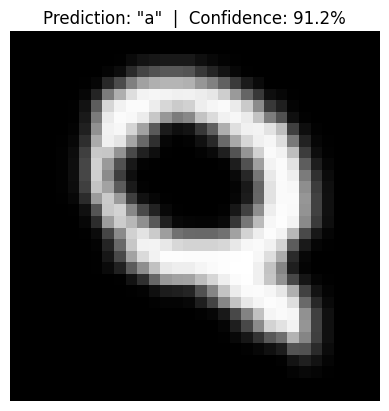

Image       : emnist_48_label_1.png
Prediction  : a
Confidence  : 91.2%
-----------------------------


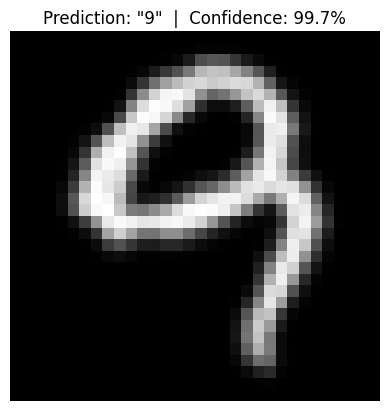

Image       : emnist_16_label_1.png
Prediction  : 9
Confidence  : 99.7%
-----------------------------


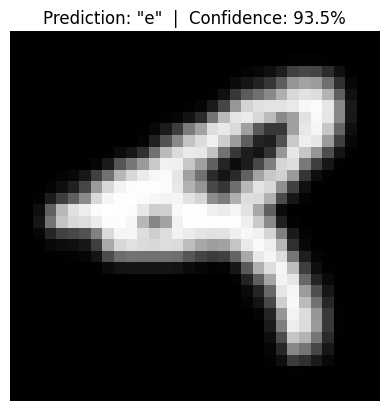

Image       : emnist_190_label_1.png
Prediction  : e
Confidence  : 93.5%
-----------------------------


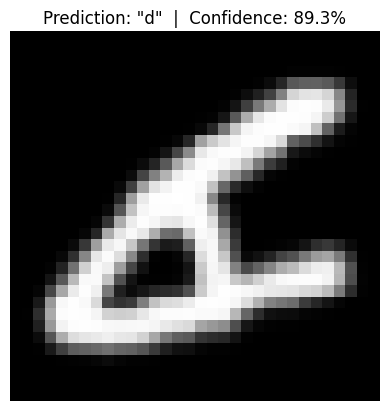

Image       : emnist_66_label_1.png
Prediction  : d
Confidence  : 89.3%
-----------------------------


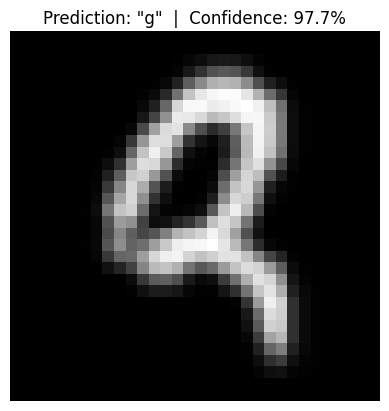

Image       : emnist_87_label_1.png
Prediction  : g
Confidence  : 97.7%
-----------------------------


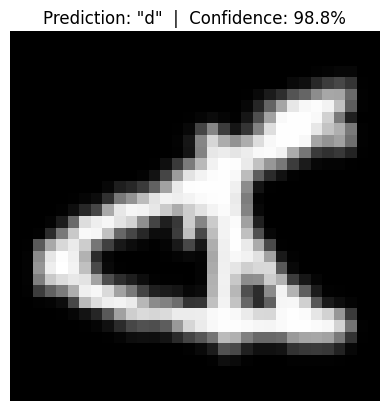

Image       : emnist_101_label_1.png
Prediction  : d
Confidence  : 98.8%
-----------------------------


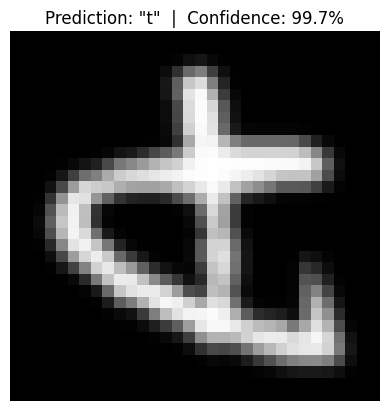

Image       : emnist_171_label_1.png
Prediction  : t
Confidence  : 99.7%
-----------------------------


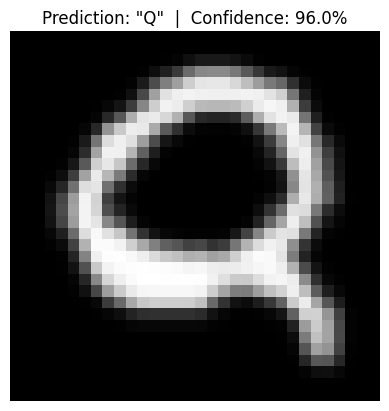

Image       : emnist_54_label_1.png
Prediction  : Q
Confidence  : 96.0%
-----------------------------


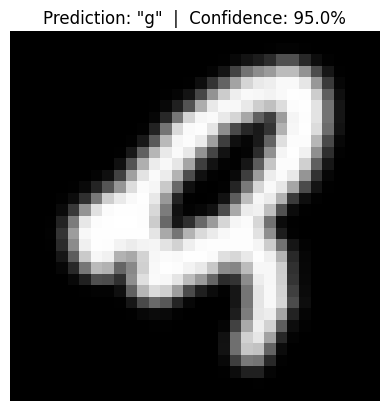

Image       : emnist_24_label_1.png
Prediction  : g
Confidence  : 95.0%
-----------------------------


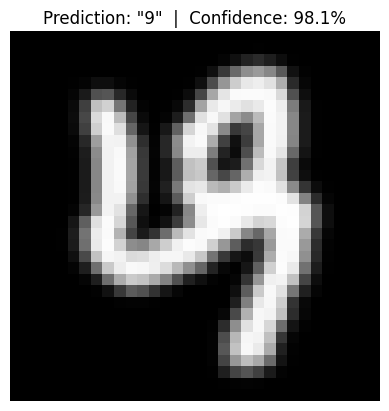

Image       : emnist_41_label_1.png
Prediction  : 9
Confidence  : 98.1%
-----------------------------


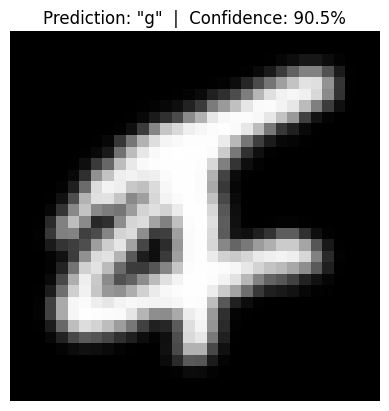

Image       : emnist_31_label_1.png
Prediction  : g
Confidence  : 90.5%
-----------------------------


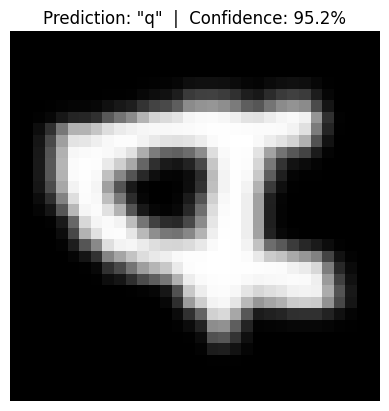

Image       : emnist_92_label_1.png
Prediction  : q
Confidence  : 95.2%
-----------------------------


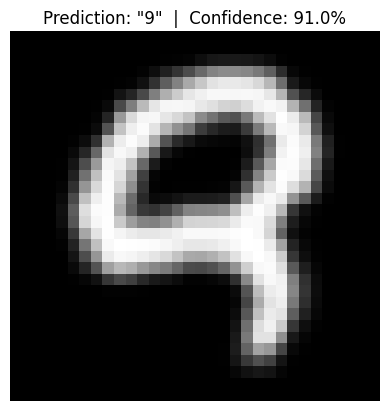

Image       : emnist_114_label_1.png
Prediction  : 9
Confidence  : 91.0%
-----------------------------


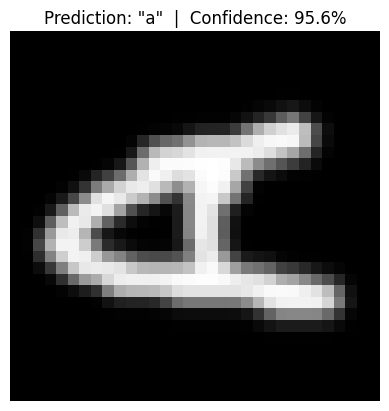

Image       : emnist_199_label_1.png
Prediction  : a
Confidence  : 95.6%
-----------------------------


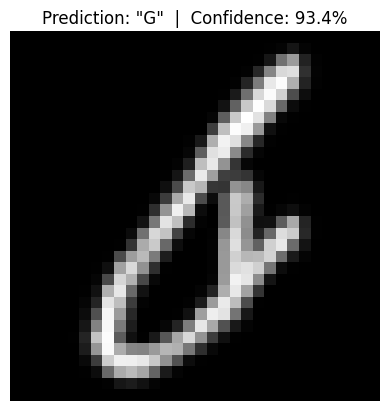

Image       : emnist_164_label_1.png
Prediction  : G
Confidence  : 93.4%
-----------------------------


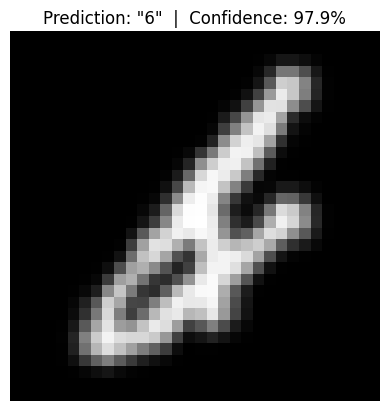

Image       : emnist_178_label_1.png
Prediction  : 6
Confidence  : 97.9%
-----------------------------


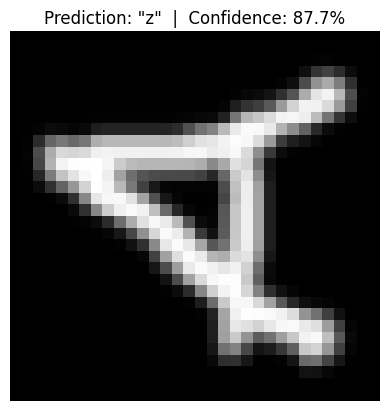

Image       : emnist_185_label_1.png
Prediction  : z
Confidence  : 87.7%
-----------------------------


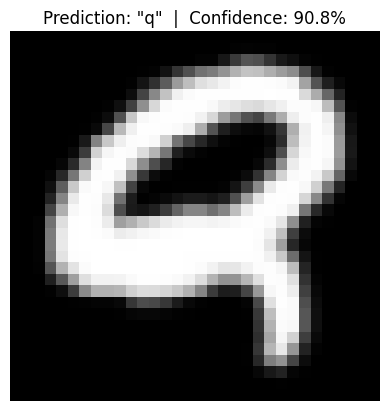

Image       : emnist_73_label_1.png
Prediction  : q
Confidence  : 90.8%
-----------------------------


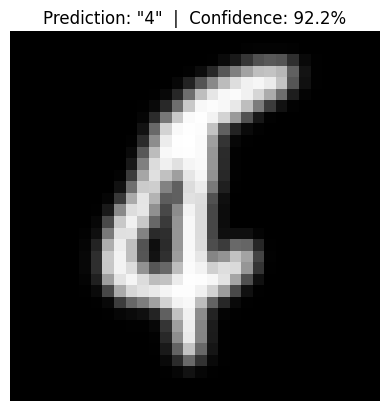

Image       : emnist_108_label_1.png
Prediction  : 4
Confidence  : 92.2%
-----------------------------


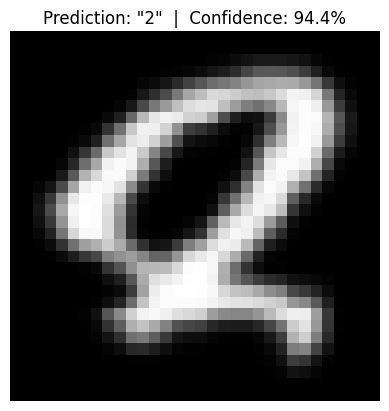

Image       : emnist_156_label_1.png
Prediction  : 2
Confidence  : 94.4%
-----------------------------


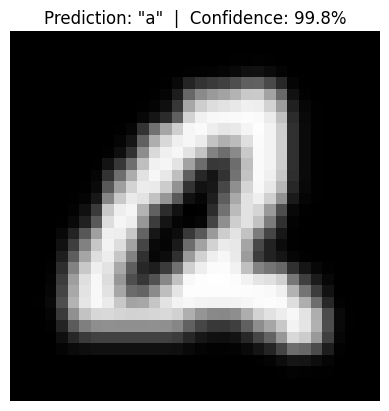

Image       : emnist_126_label_1.png
Prediction  : a
Confidence  : 99.8%
-----------------------------


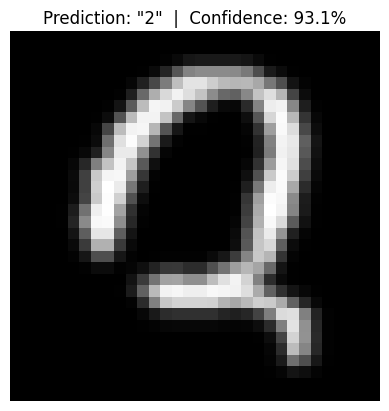

Image       : emnist_2_label_1.png
Prediction  : 2
Confidence  : 93.1%
-----------------------------


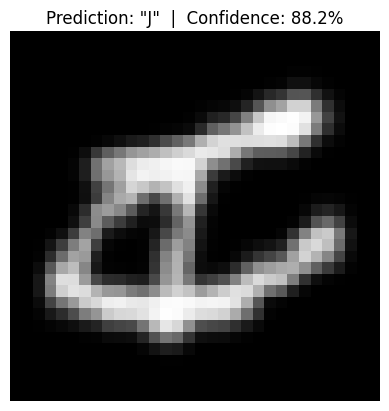

Image       : emnist_161_label_1.png
Prediction  : J
Confidence  : 88.2%
-----------------------------


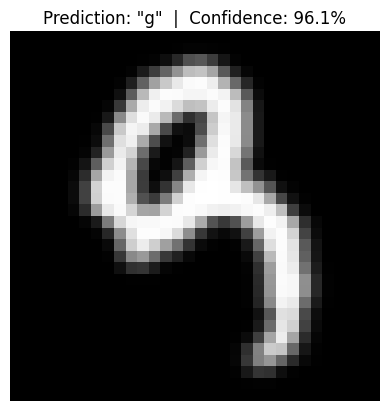

Image       : emnist_111_label_1.png
Prediction  : g
Confidence  : 96.1%
-----------------------------


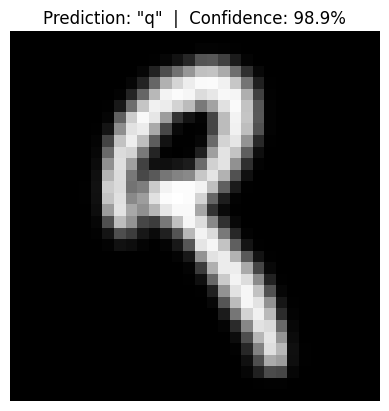

Image       : emnist_97_label_1.png
Prediction  : q
Confidence  : 98.9%
-----------------------------


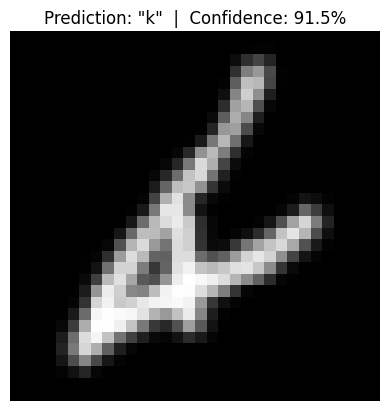

Image       : emnist_34_label_1.png
Prediction  : k
Confidence  : 91.5%
-----------------------------


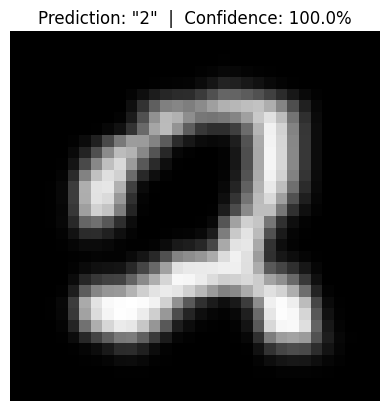

Image       : emnist_44_label_1.png
Prediction  : 2
Confidence  : 100.0%
-----------------------------


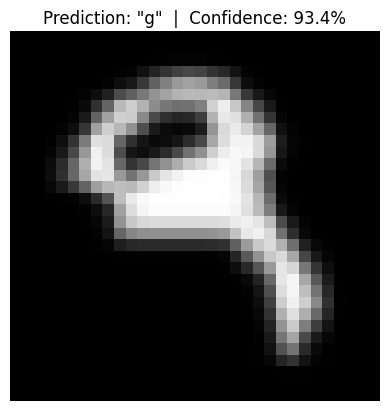

Image       : emnist_123_label_1.png
Prediction  : g
Confidence  : 93.4%
-----------------------------


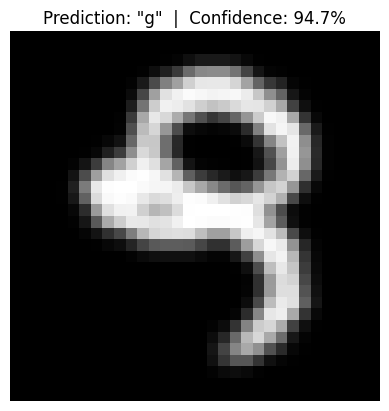

Image       : emnist_58_label_1.png
Prediction  : g
Confidence  : 94.7%
-----------------------------


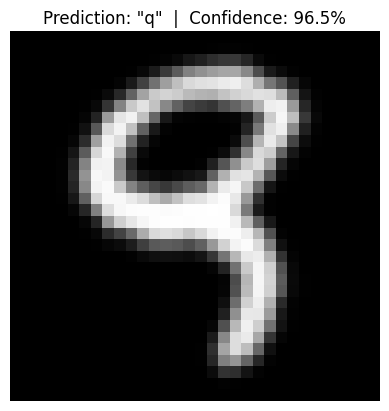

Image       : emnist_7_label_1.png
Prediction  : q
Confidence  : 96.5%
-----------------------------


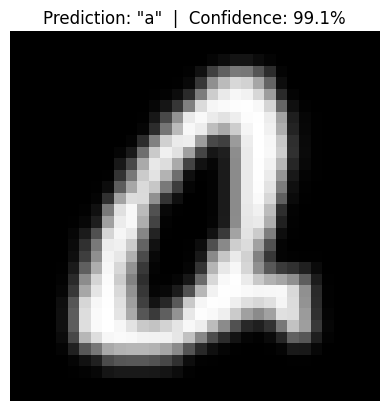

Image       : emnist_153_label_1.png
Prediction  : a
Confidence  : 99.1%
-----------------------------


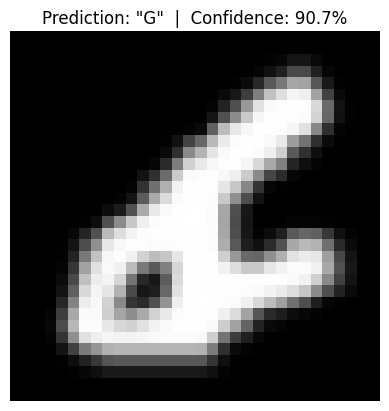

Image       : emnist_28_label_1.png
Prediction  : G
Confidence  : 90.7%
-----------------------------


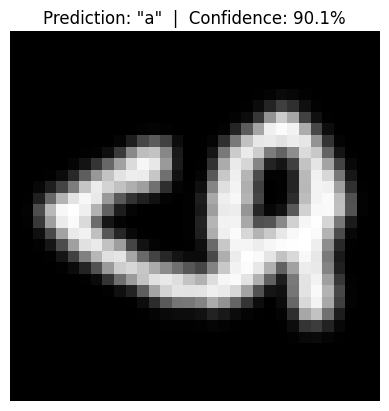

Image       : emnist_76_label_1.png
Prediction  : a
Confidence  : 90.1%
-----------------------------


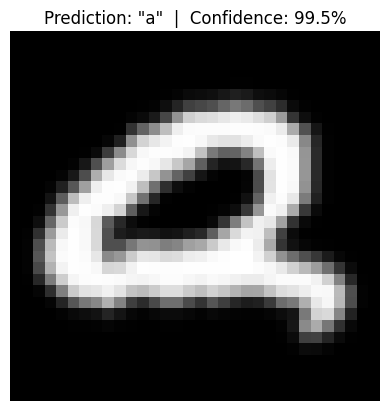

Image       : emnist_180_label_1.png
Prediction  : a
Confidence  : 99.5%
-----------------------------


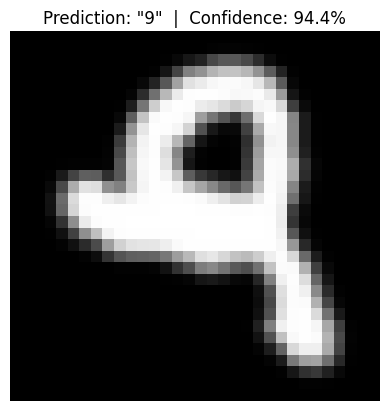

Image       : emnist_63_label_1.png
Prediction  : 9
Confidence  : 94.4%
-----------------------------


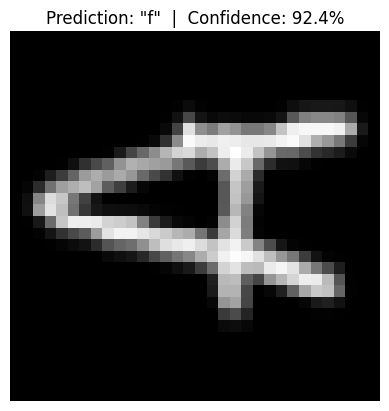

Image       : emnist_118_label_1.png
Prediction  : f
Confidence  : 92.4%
-----------------------------


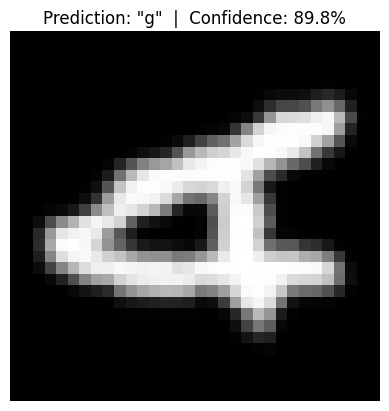

Image       : emnist_195_label_1.png
Prediction  : g
Confidence  : 89.8%
-----------------------------


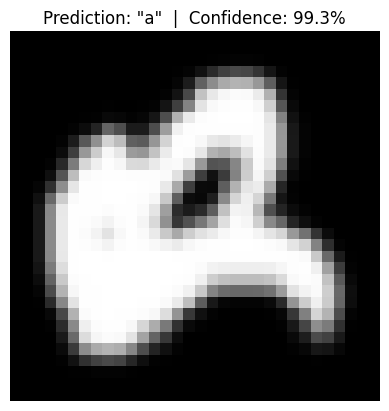

Image       : emnist_13_label_1.png
Prediction  : a
Confidence  : 99.3%
-----------------------------


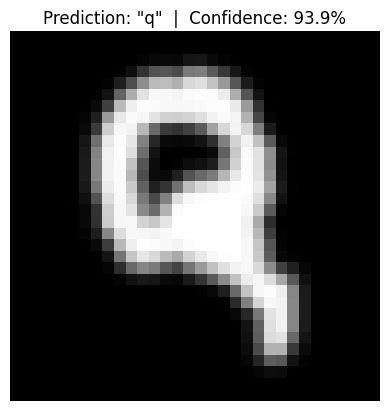

Image       : emnist_168_label_1.png
Prediction  : q
Confidence  : 93.9%
-----------------------------


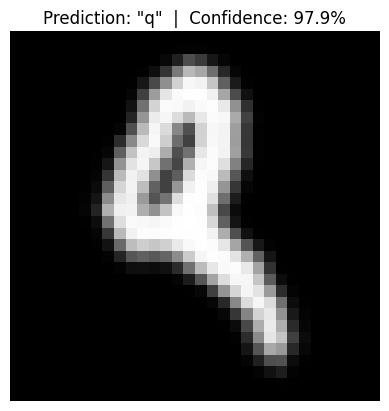

Image       : emnist_136_label_1.png
Prediction  : q
Confidence  : 97.9%
-----------------------------


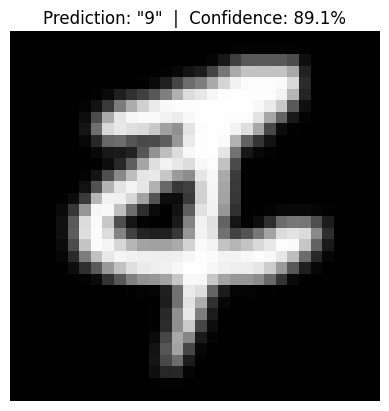

Image       : emnist_146_label_1.png
Prediction  : 9
Confidence  : 89.1%
-----------------------------


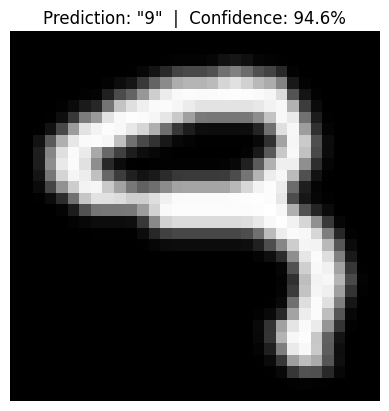

Image       : emnist_21_label_1.png
Prediction  : 9
Confidence  : 94.6%
-----------------------------


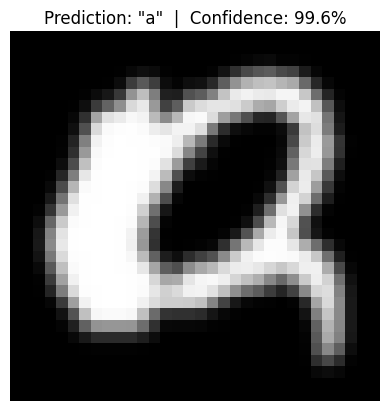

Image       : emnist_51_label_1.png
Prediction  : a
Confidence  : 99.6%
-----------------------------


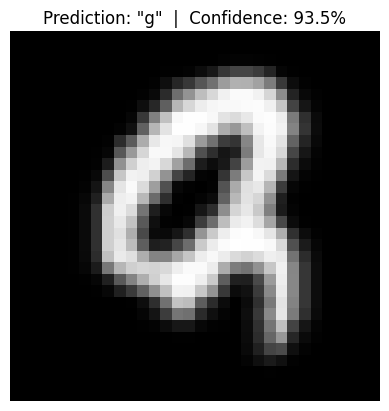

Image       : emnist_174_label_1.png
Prediction  : g
Confidence  : 93.5%
-----------------------------


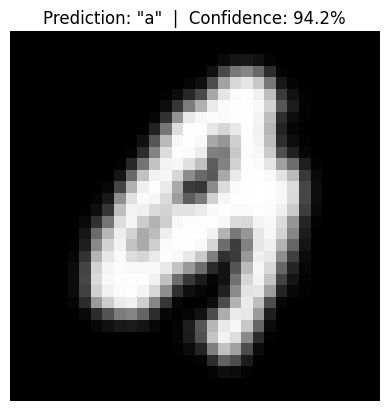

Image       : emnist_189_label_1.png
Prediction  : a
Confidence  : 94.2%
-----------------------------


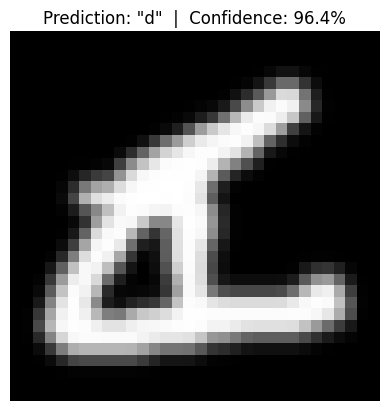

Image       : emnist_104_label_1.png
Prediction  : d
Confidence  : 96.4%
-----------------------------


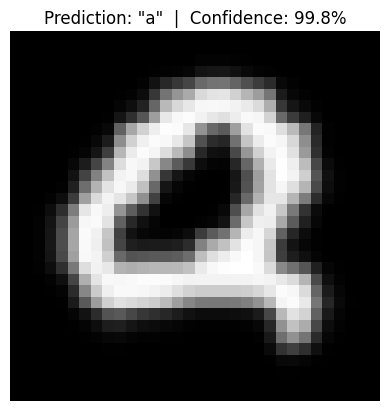

Image       : emnist_82_label_1.png
Prediction  : a
Confidence  : 99.8%
-----------------------------


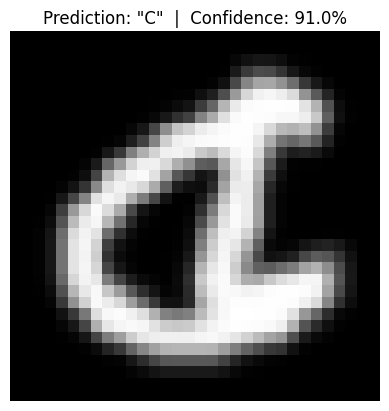

Image       : emnist_177_label_1.png
Prediction  : C
Confidence  : 91.0%
-----------------------------


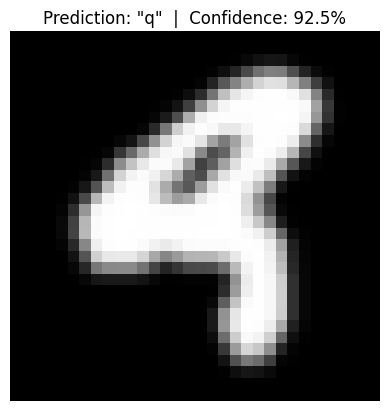

Image       : emnist_81_label_1.png
Prediction  : q
Confidence  : 92.5%
-----------------------------


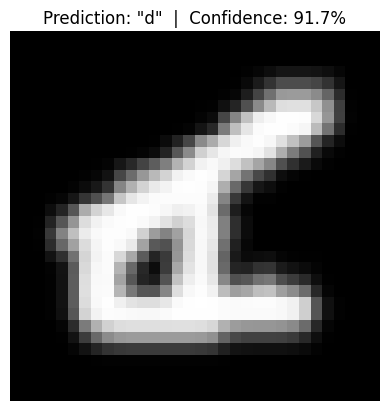

Image       : emnist_107_label_1.png
Prediction  : d
Confidence  : 91.7%
-----------------------------


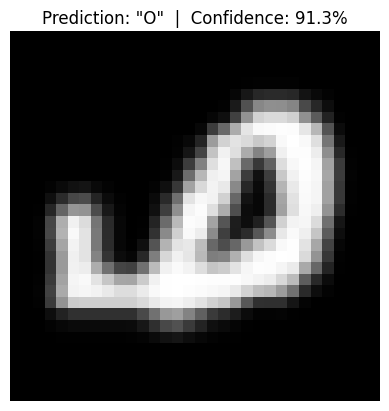

Image       : emnist_159_label_1.png
Prediction  : O
Confidence  : 91.3%
-----------------------------


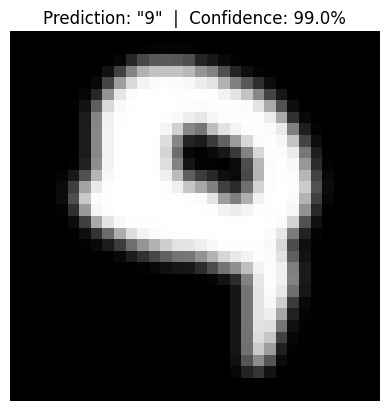

Image       : emnist_22_label_1.png
Prediction  : 9
Confidence  : 99.0%
-----------------------------


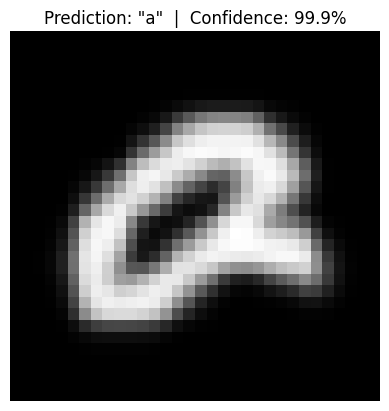

Image       : emnist_129_label_1.png
Prediction  : a
Confidence  : 99.9%
-----------------------------


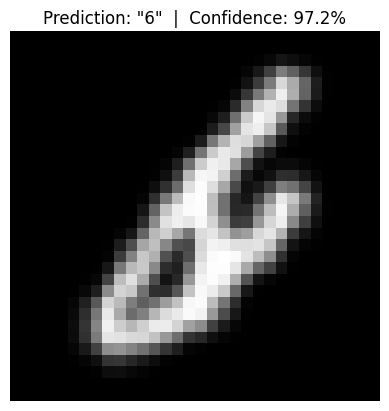

Image       : emnist_52_label_1.png
Prediction  : 6
Confidence  : 97.2%
-----------------------------


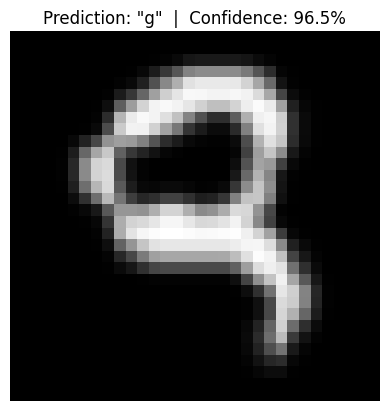

Image       : emnist_135_label_1.png
Prediction  : g
Confidence  : 96.5%
-----------------------------


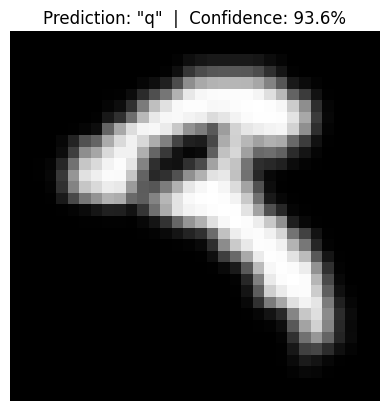

Image       : emnist_145_label_1.png
Prediction  : q
Confidence  : 93.6%
-----------------------------


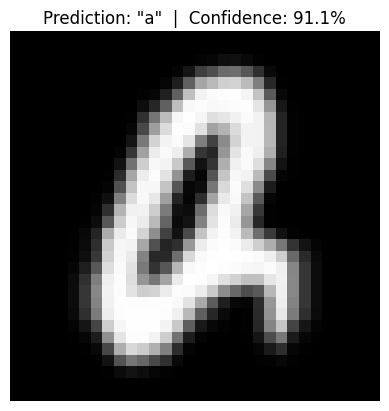

Image       : emnist_60_label_1.png
Prediction  : a
Confidence  : 91.1%
-----------------------------


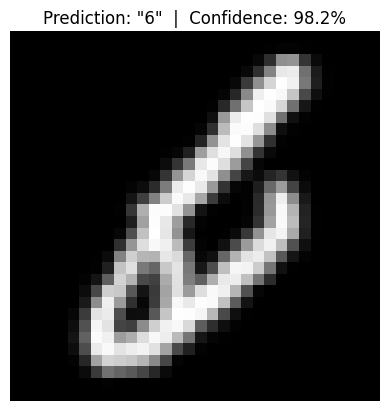

Image       : emnist_10_label_1.png
Prediction  : 6
Confidence  : 98.2%
-----------------------------


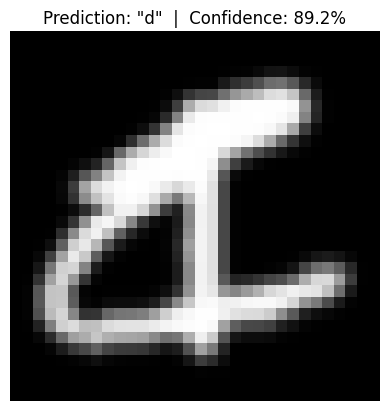

Image       : emnist_196_label_1.png
Prediction  : d
Confidence  : 89.2%
-----------------------------


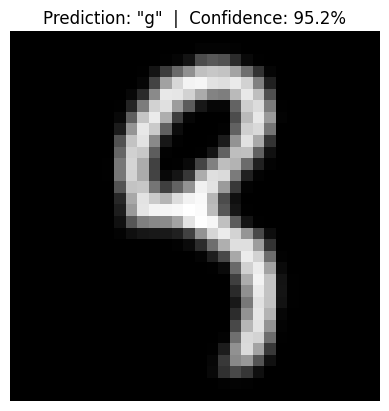

Image       : emnist_75_label_1.png
Prediction  : g
Confidence  : 95.2%
-----------------------------


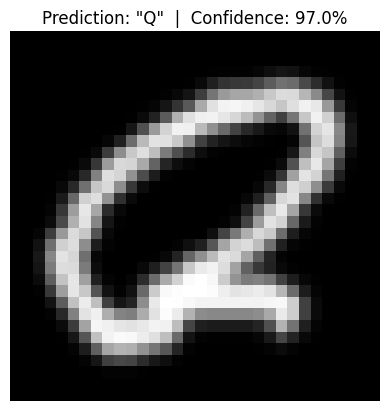

Image       : emnist_88_label_1.png
Prediction  : Q
Confidence  : 97.0%
-----------------------------


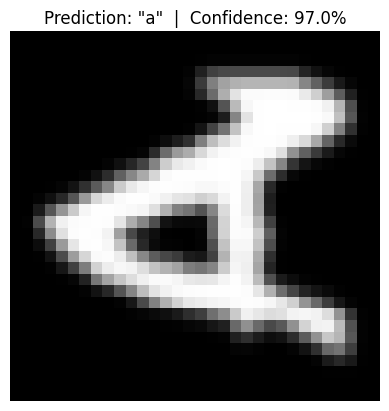

Image       : emnist_183_label_1.png
Prediction  : a
Confidence  : 97.0%
-----------------------------


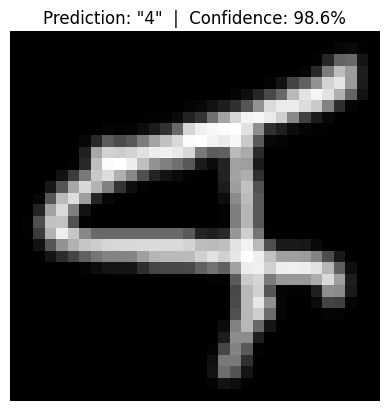

Image       : emnist_4_label_1.png
Prediction  : 4
Confidence  : 98.6%
-----------------------------


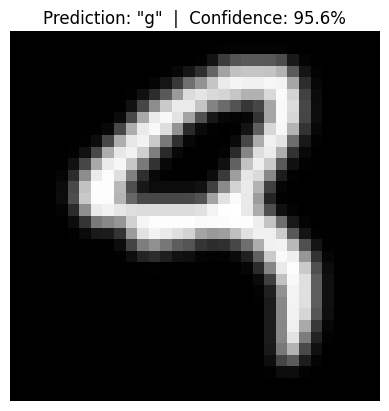

Image       : emnist_120_label_1.png
Prediction  : g
Confidence  : 95.6%
-----------------------------


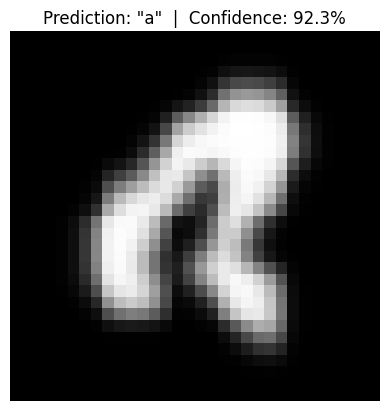

Image       : emnist_150_label_1.png
Prediction  : a
Confidence  : 92.3%
-----------------------------


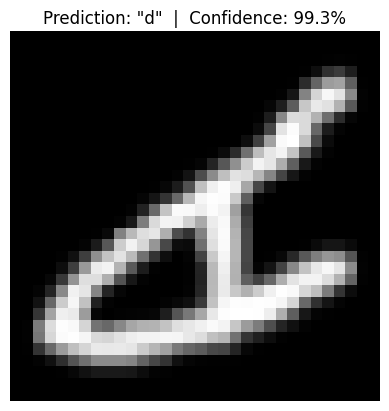

Image       : emnist_37_label_1.png
Prediction  : d
Confidence  : 99.3%
-----------------------------


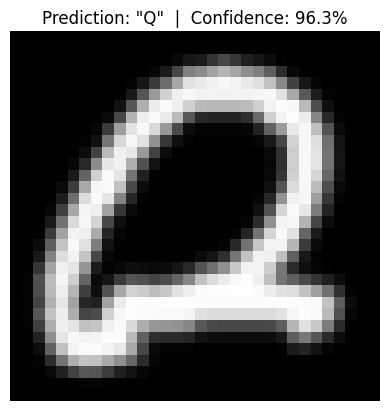

Image       : emnist_47_label_1.png
Prediction  : Q
Confidence  : 96.3%
-----------------------------


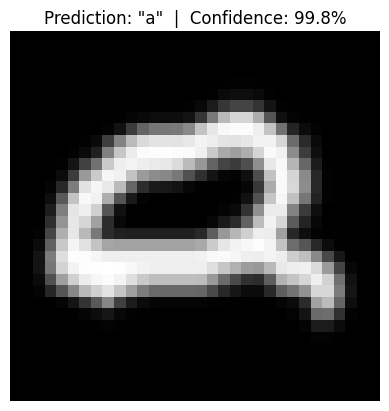

Image       : emnist_19_label_1.png
Prediction  : a
Confidence  : 99.8%
-----------------------------


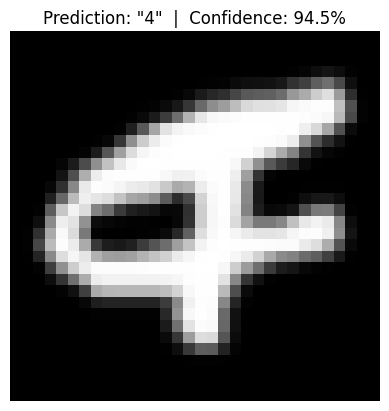

Image       : emnist_162_label_1.png
Prediction  : 4
Confidence  : 94.5%
-----------------------------


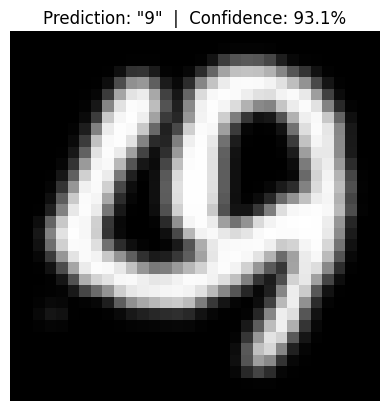

Image       : emnist_94_label_1.png
Prediction  : 9
Confidence  : 93.1%
-----------------------------


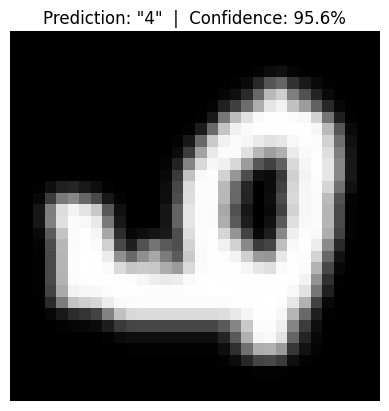

Image       : emnist_69_label_1.png
Prediction  : 4
Confidence  : 95.6%
-----------------------------


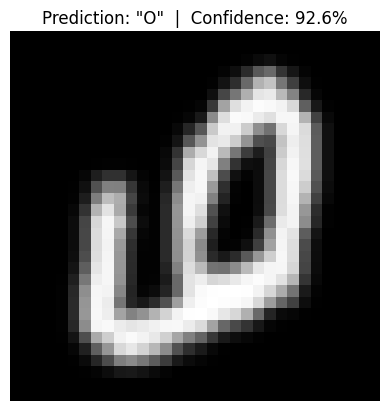

Image       : emnist_112_label_1.png
Prediction  : O
Confidence  : 92.6%
-----------------------------


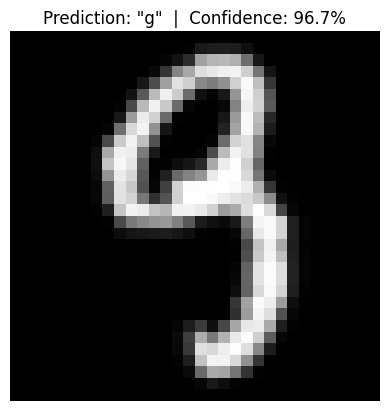

Image       : emnist_155_label_1.png
Prediction  : g
Confidence  : 96.7%
-----------------------------


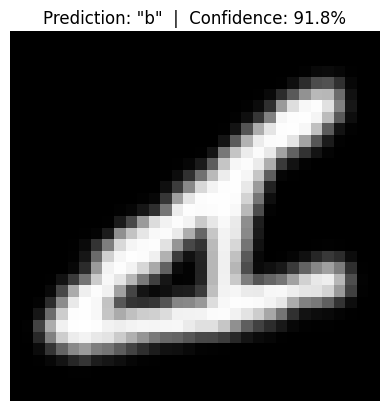

Image       : emnist_1_label_1.png
Prediction  : b
Confidence  : 91.8%
-----------------------------


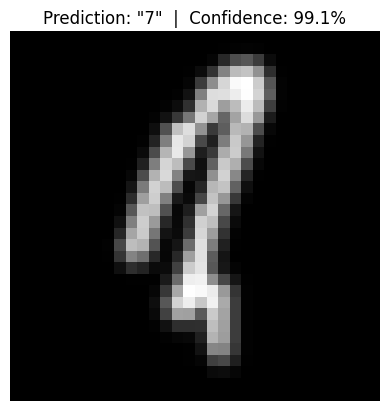

Image       : emnist_125_label_1.png
Prediction  : 7
Confidence  : 99.1%
-----------------------------


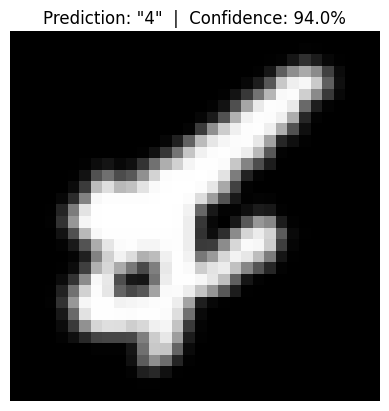

Image       : emnist_186_label_1.png
Prediction  : 4
Confidence  : 94.0%
-----------------------------


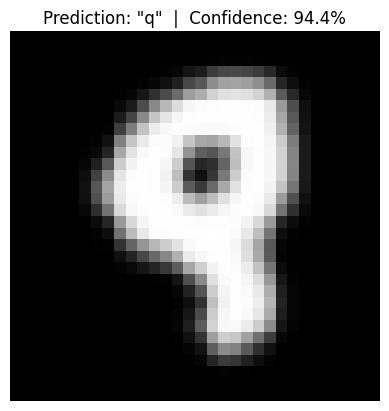

Image       : emnist_70_label_1.png
Prediction  : q
Confidence  : 94.4%
-----------------------------


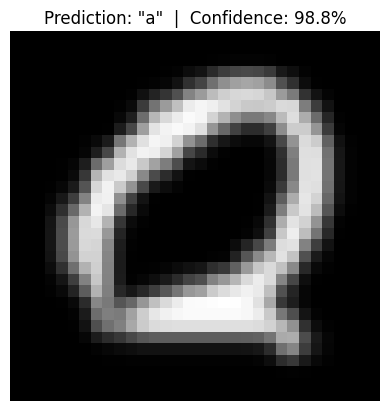

Image       : emnist_117_label_1.png
Prediction  : a
Confidence  : 98.8%
-----------------------------


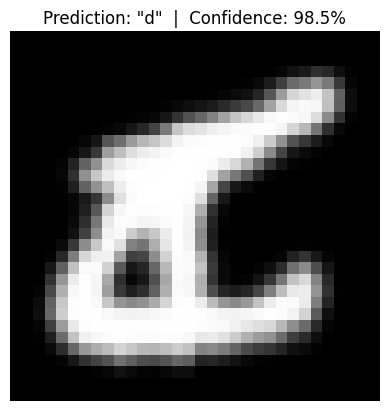

Image       : emnist_91_label_1.png
Prediction  : d
Confidence  : 98.5%
-----------------------------


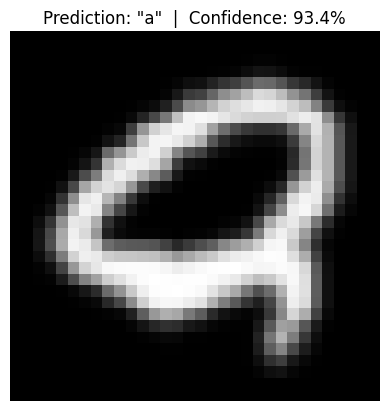

Image       : emnist_167_label_1.png
Prediction  : a
Confidence  : 93.4%
-----------------------------


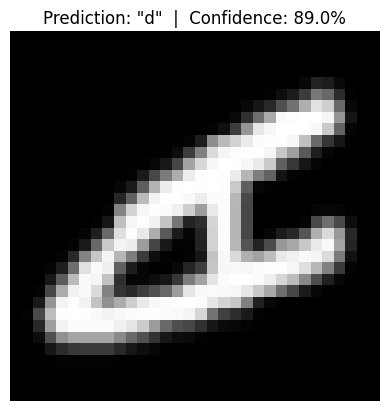

Image       : emnist_139_label_1.png
Prediction  : d
Confidence  : 89.0%
-----------------------------


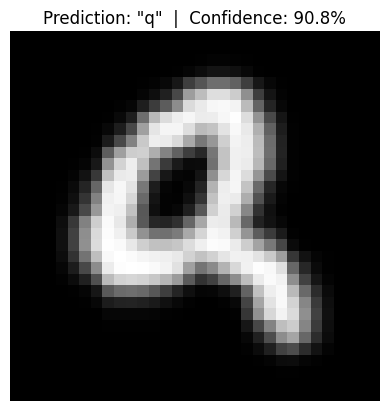

Image       : emnist_42_label_1.png
Prediction  : q
Confidence  : 90.8%
-----------------------------


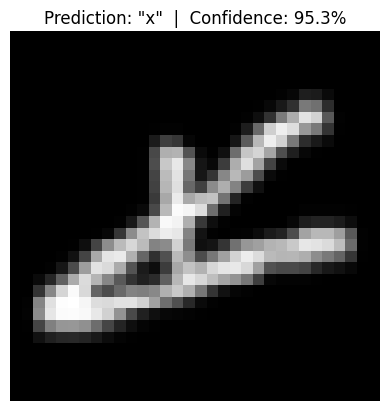

Image       : emnist_149_label_1.png
Prediction  : x
Confidence  : 95.3%
-----------------------------


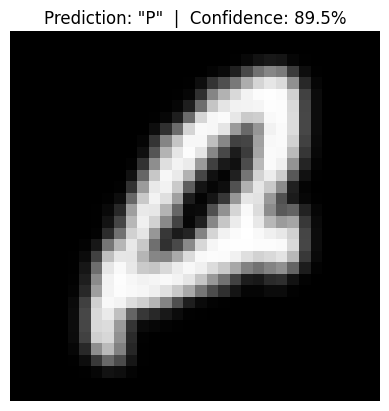

Image       : emnist_32_label_1.png
Prediction  : P
Confidence  : 89.5%
-----------------------------


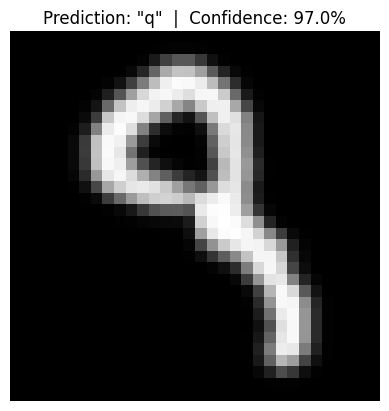

Image       : emnist_8_label_1.png
Prediction  : q
Confidence  : 97.0%
-----------------------------


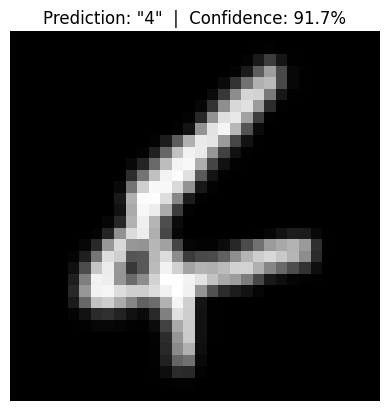

Image       : emnist_57_label_1.png
Prediction  : 4
Confidence  : 91.7%
-----------------------------


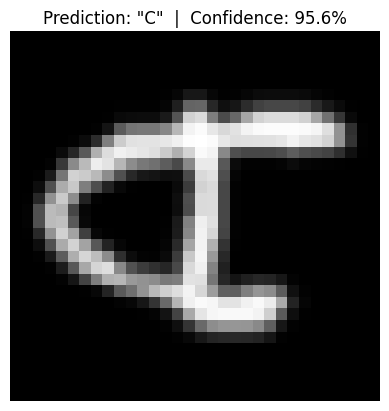

Image       : emnist_27_label_1.png
Prediction  : C
Confidence  : 95.6%
-----------------------------


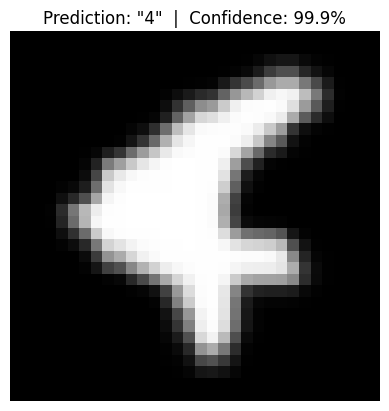

Image       : emnist_79_label_1.png
Prediction  : 4
Confidence  : 99.9%
-----------------------------


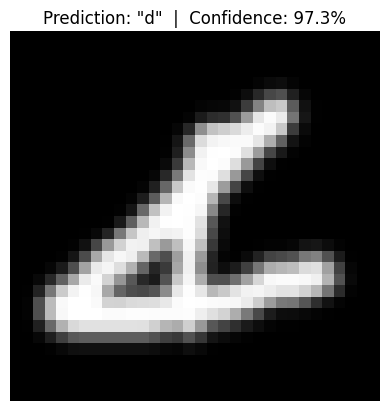

Image       : emnist_102_label_1.png
Prediction  : d
Confidence  : 97.3%
-----------------------------


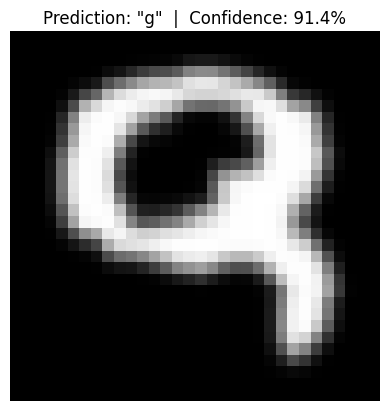

Image       : emnist_84_label_1.png
Prediction  : g
Confidence  : 91.4%
-----------------------------


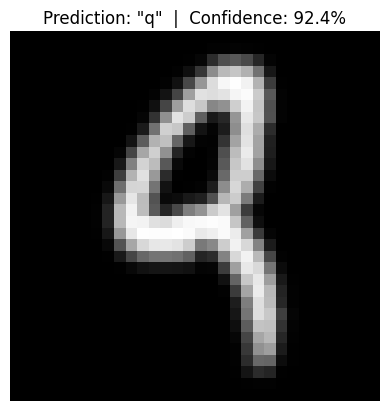

Image       : emnist_172_label_1.png
Prediction  : q
Confidence  : 92.4%
-----------------------------


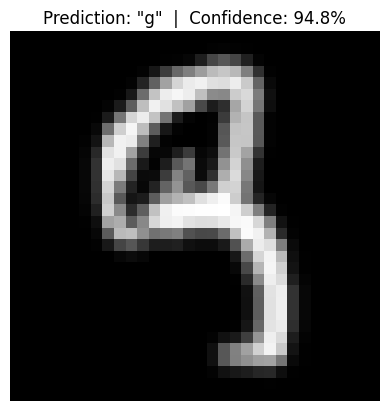

Image       : emnist_193_label_1.png
Prediction  : g
Confidence  : 94.8%
-----------------------------


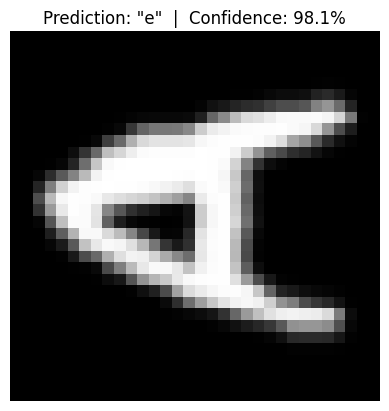

Image       : emnist_15_label_1.png
Prediction  : e
Confidence  : 98.1%
-----------------------------


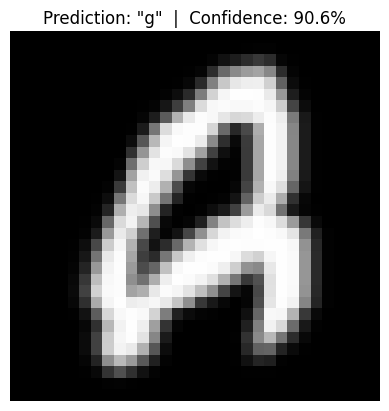

Image       : emnist_98_label_1.png
Prediction  : g
Confidence  : 90.6%
-----------------------------


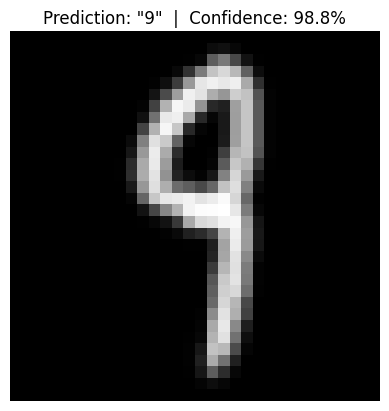

Image       : emnist_65_label_1.png
Prediction  : 9
Confidence  : 98.8%
-----------------------------


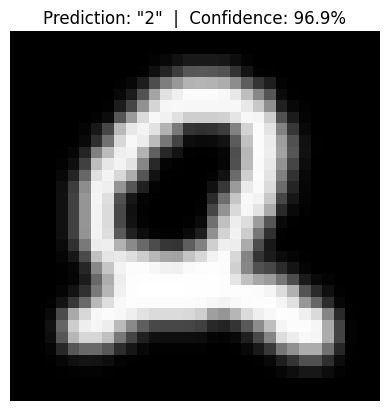

Image       : emnist_140_label_1.png
Prediction  : 2
Confidence  : 96.9%
-----------------------------


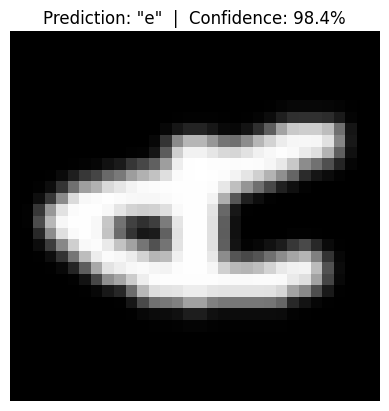

Image       : emnist_130_label_1.png
Prediction  : e
Confidence  : 98.4%
-----------------------------


In [32]:
import os
from PIL import Image, ImageOps
import torch
import matplotlib.pyplot as plt

TEST_FOLDER = "test_images"

for img_name in os.listdir(TEST_FOLDER):

    img_path = os.path.join(TEST_FOLDER, img_name)

    # Load image
    img_pil = Image.open(img_path).convert('L')

    # Improve contrast
    img_pil = ImageOps.autocontrast(img_pil)

    # Apply same transform as training
    test_img_tensor = make_transform(False)(img_pil).unsqueeze(0)

    # Predict
    pred_text, confidence = predict_image(test_img_tensor)

    # Display
    img_np = test_img_tensor.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5

    plt.imshow(img_np, cmap='gray')
    plt.title(f'Prediction: "{pred_text}"  |  Confidence: {confidence*100:.1f}%')
    plt.axis('off')
    plt.show()

    print(f'Image       : {img_name}')
    print(f'Prediction  : {pred_text}')
    print(f'Confidence  : {confidence*100:.1f}%')
    print('-----------------------------')